                            OLS Regression Results                            
Dep. Variable:                  log_h   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     209.1
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.29e-44
Time:                        09:39:44   Log-Likelihood:                -1618.6
No. Observations:                1370   AIC:                             3241.
Df Residuals:                    1368   BIC:                             3252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.6720      0.450    -14.817      0.0

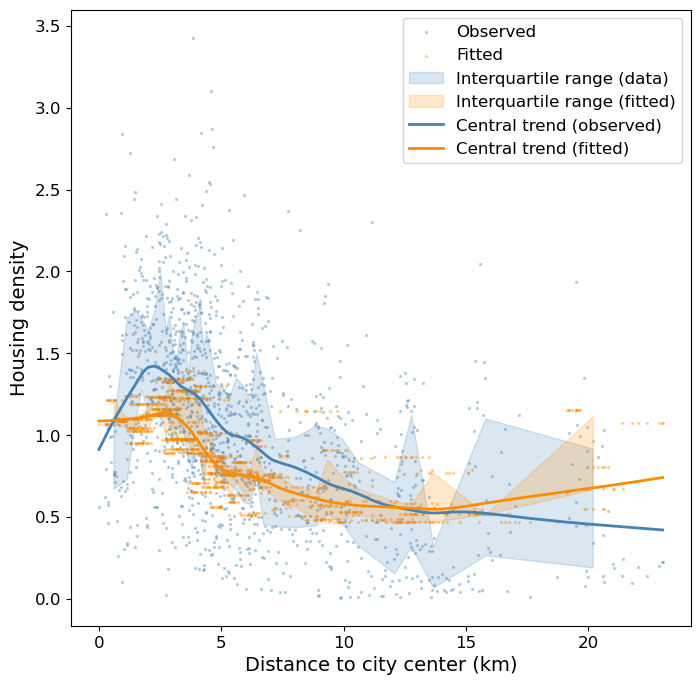

FIXED_COST_CAR:  142.092537556624
LAMBDA:  382.2051441633189
x = [142.092537556624, 382.2051441633189, 1083.9556155738962, 1142.9516601013252, 1146.2272107675826, 1148.6986016156873, 1065.9823687709936, 1100.6640561009372, 1223.60637861022, 1187.5399392846898, 1752.965017979425, 1964.7977334095121, 1907.7503202791158, 1829.4047188205075, 1766.8678868521479, 1742.6365563502932, 2094.465935615433, 1994.263633582721, 2599.9122183443446, 2655.6598729802818, 2683.131155461686, 2645.62191361995, 2540.949375462869, 2544.8826852456455, 2858.3931193074236, 2816.8841047341657]
error_mode_by_tract = 69184.72341270052
error_mode_AMB = 0.0018188166432082653
error_employment = 5507.9999999999745
estimated_wage_LOW 1160.062537195538
estimated_wage_MED 1992.1177231516112
estimated_wage_HIGH 2763.0750771632784
error_wage = 89.10246761536133
error_spatial_wage = 311.8212940716171
Modal share of public transport (%): 53
Modal share of public transport (%): 51
Modal share of public transport (%): 54
Modal

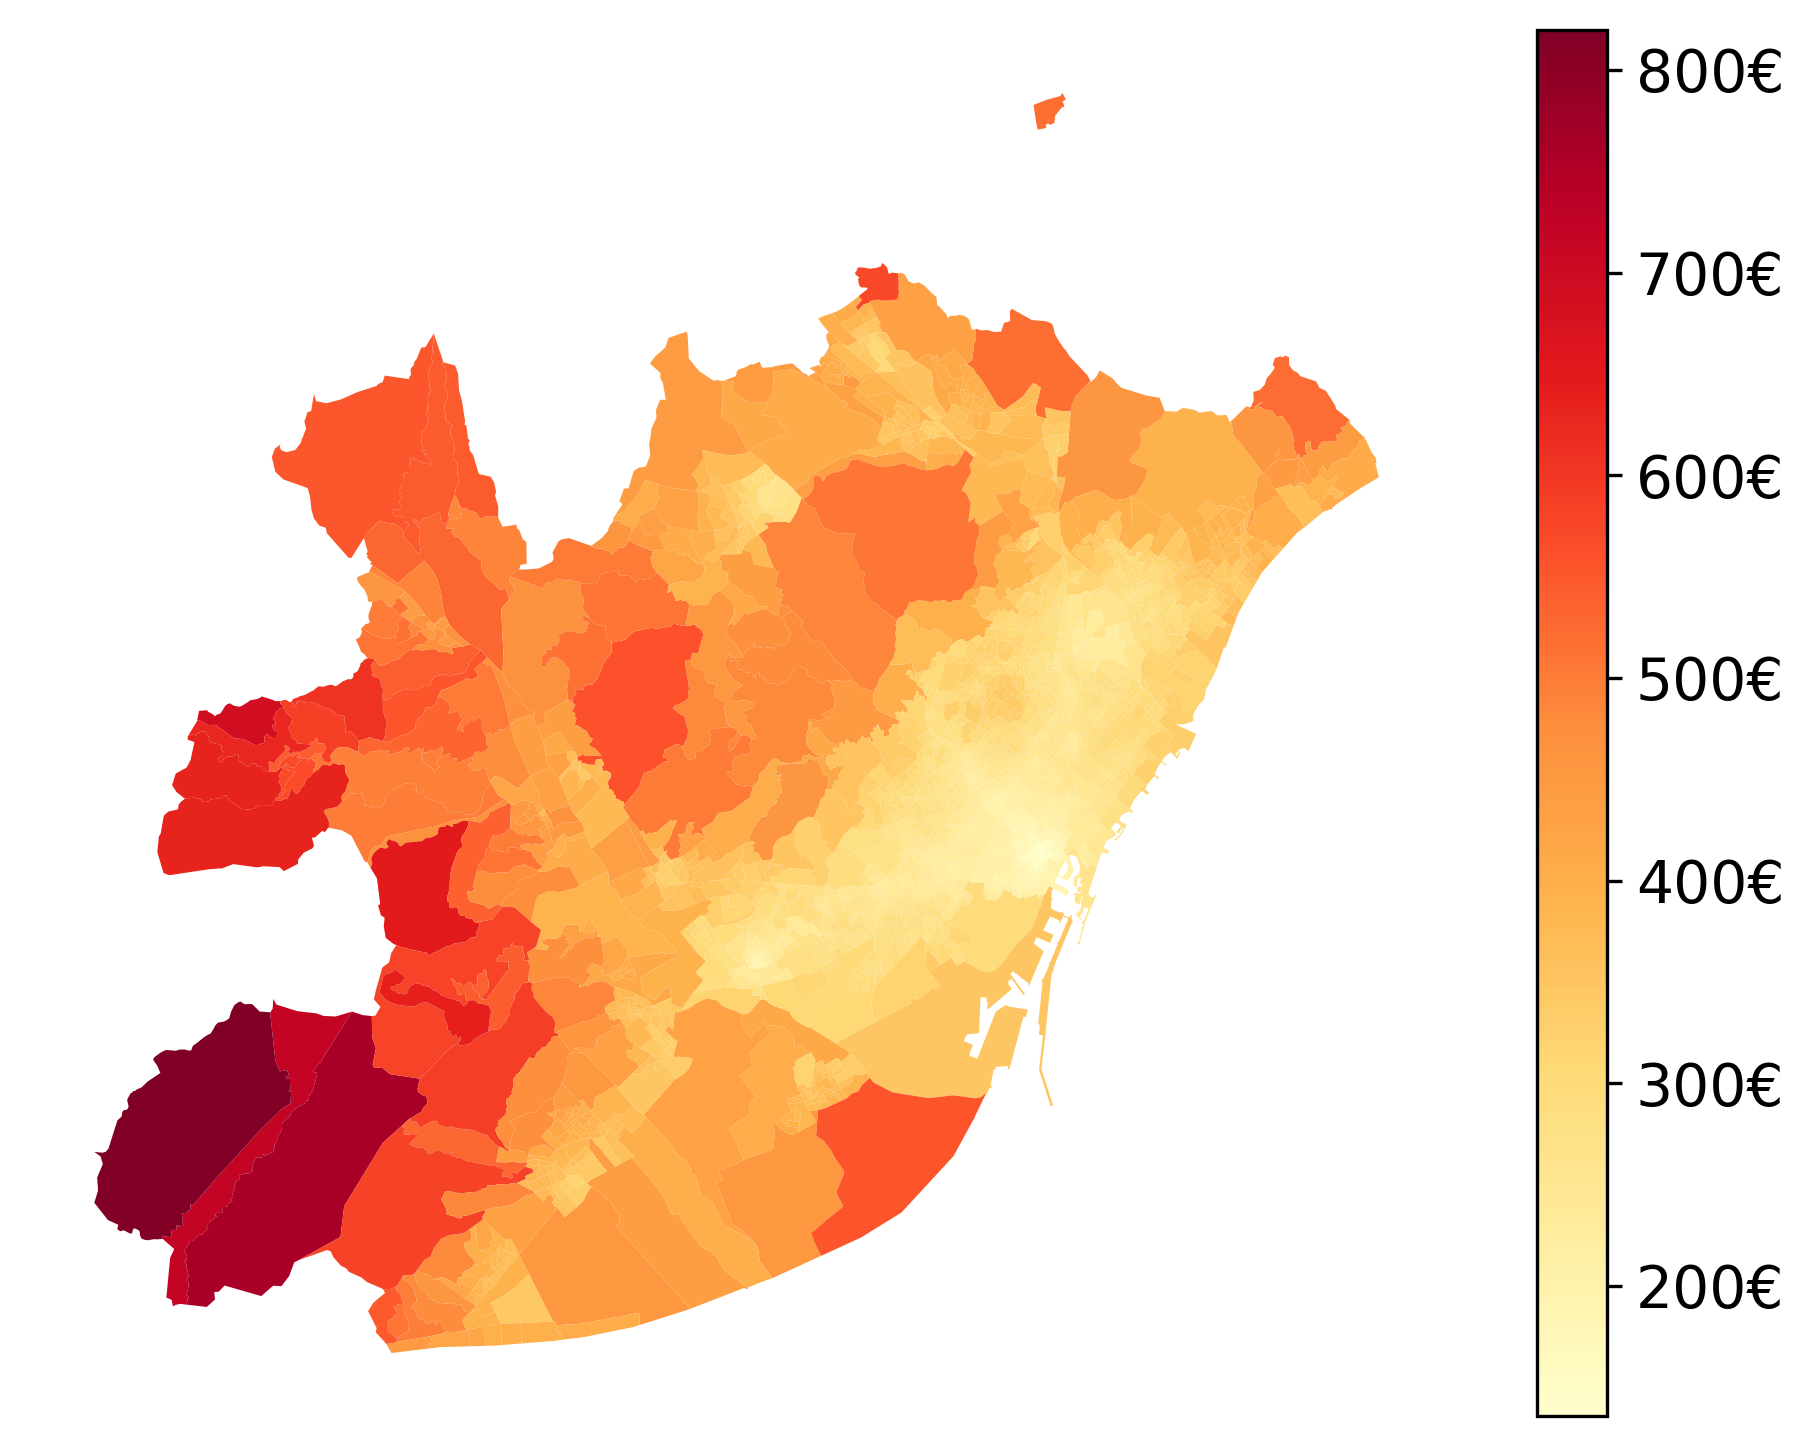

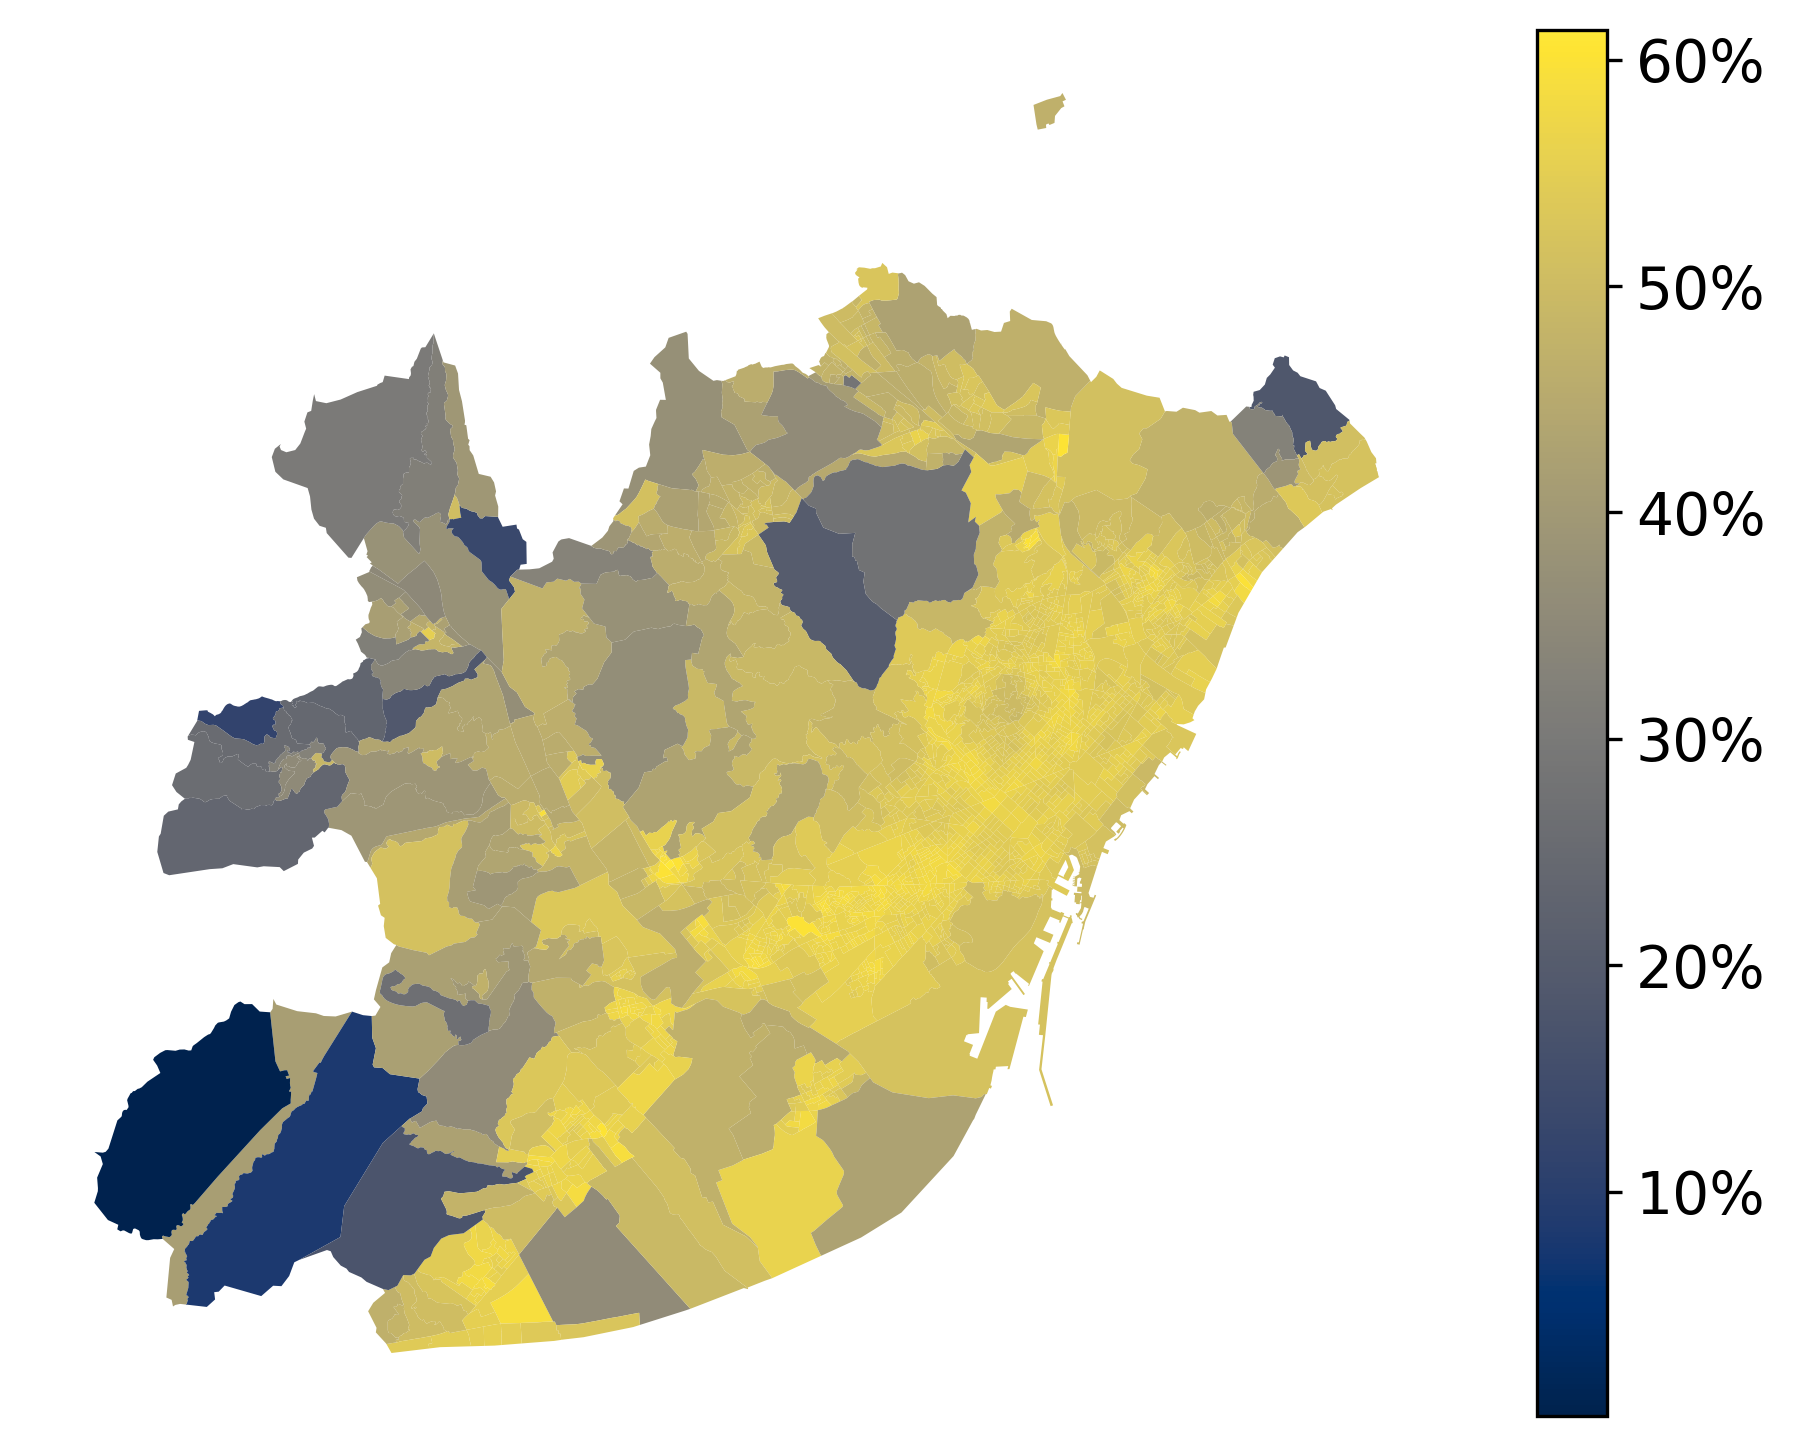

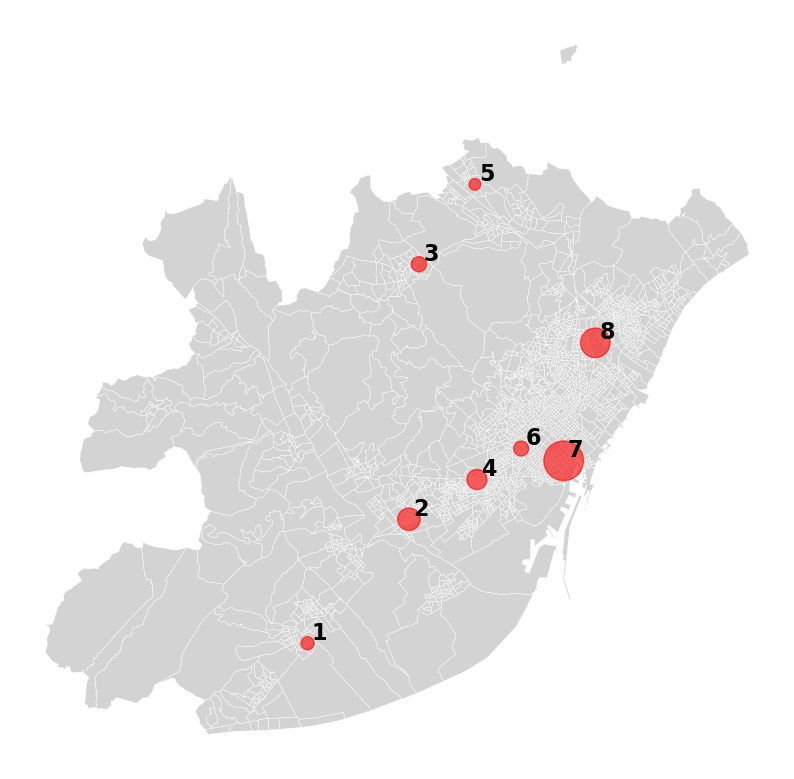

BETA: 0.4523622733231664
                            OLS Regression Results                            
Dep. Variable:                  log_A   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     16.72
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.98e-42
Time:                        09:39:51   Log-Likelihood:                 2182.9
No. Observations:                2149   AIC:                            -4334.
Df Residuals:                    2133   BIC:                            -4243.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
c

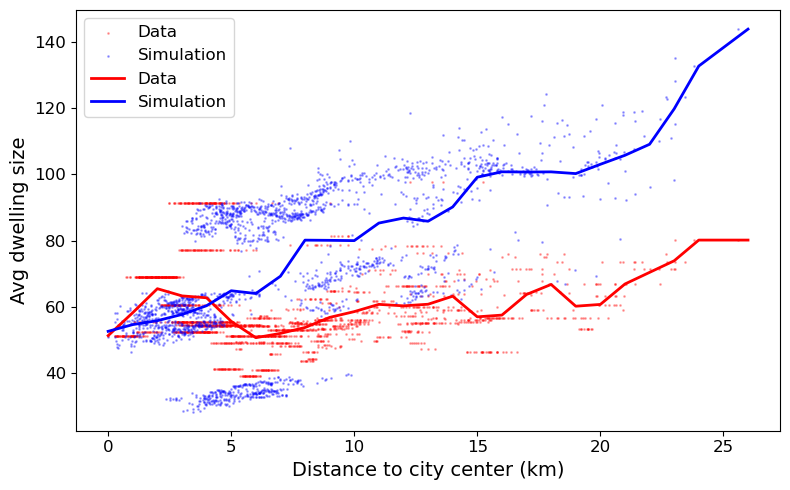

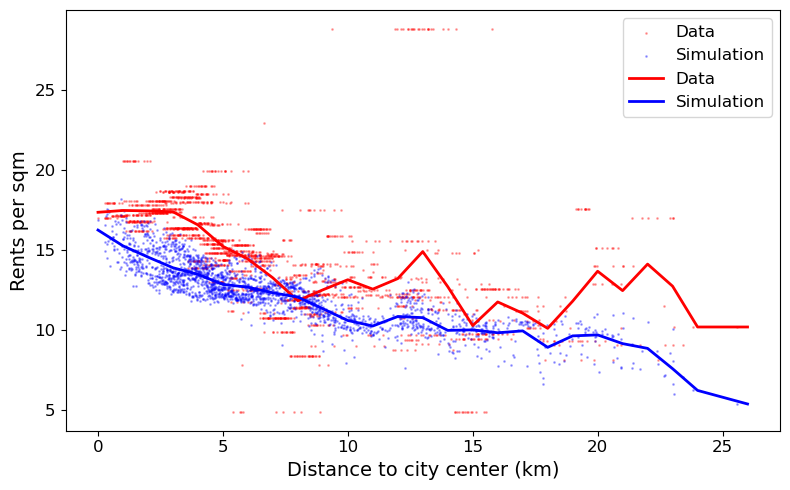

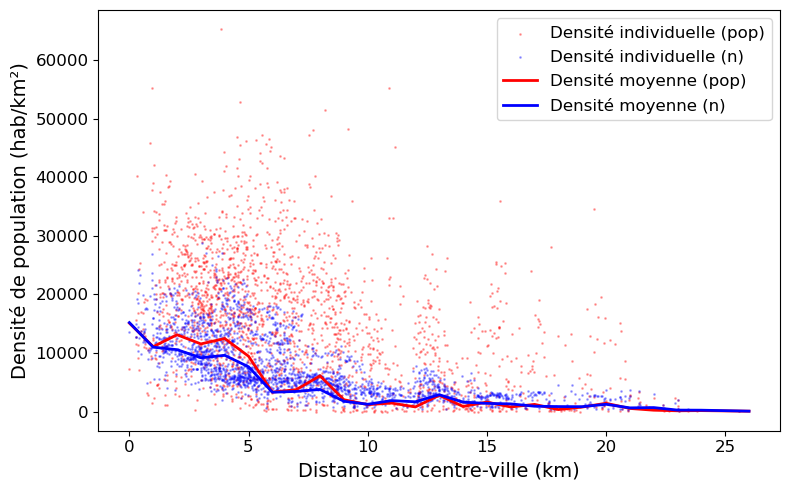

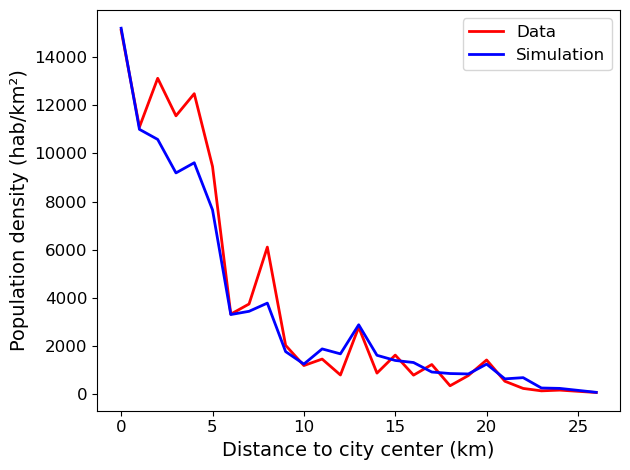

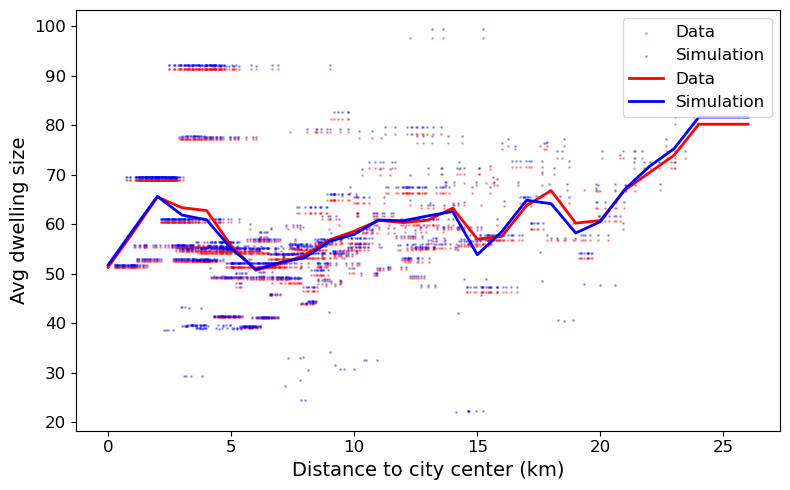

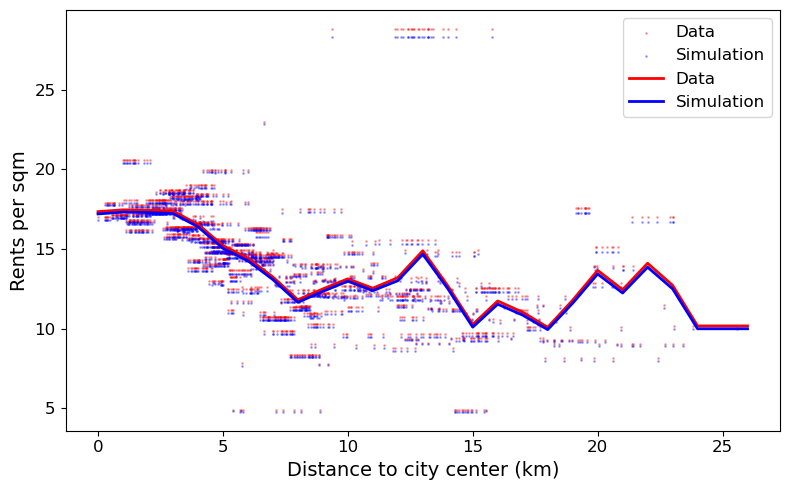

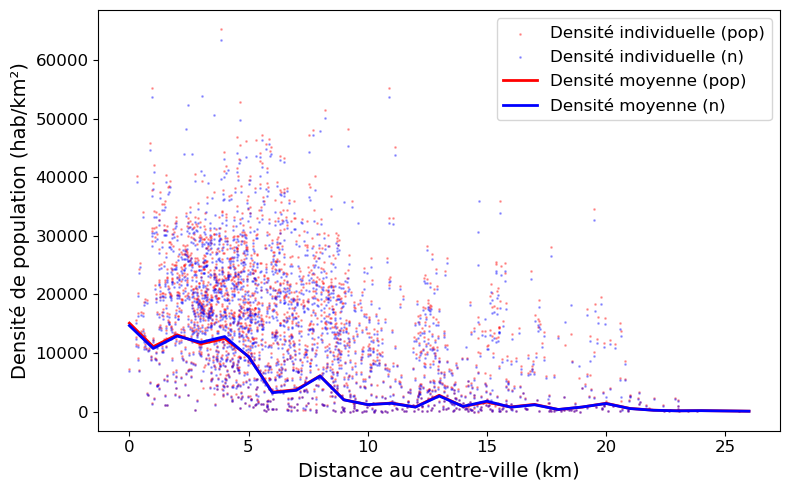

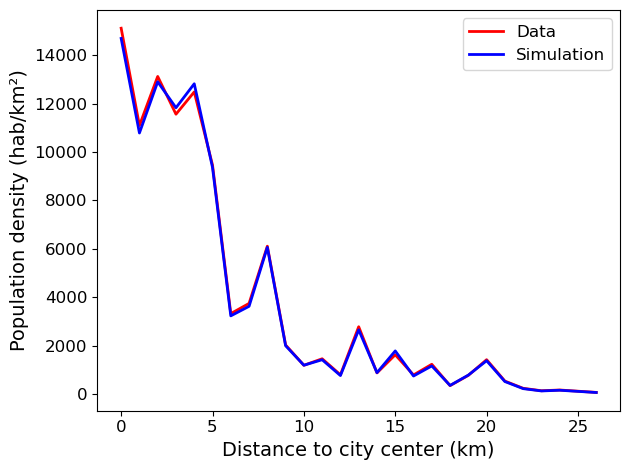

LOW
Estimated share in tax zone: 78 %
Actual share in tax zone: 63 %
MED
Estimated share in tax zone: 72 %
Actual share in tax zone: 55 %
HIGH
Estimated share in tax zone: 33 %
Actual share in tax zone: 60 %
SignificanceResult(statistic=0.5318516372448164, pvalue=2.0270998208997483e-81)


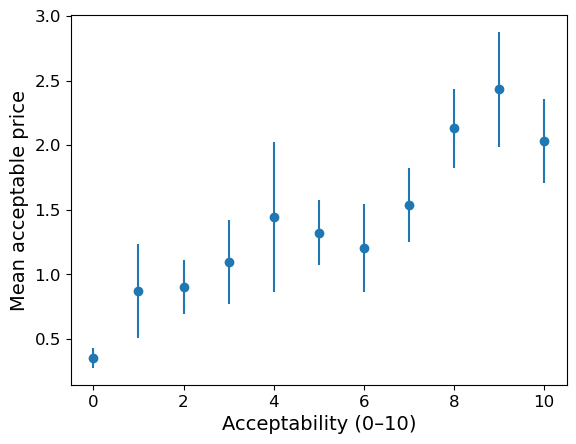

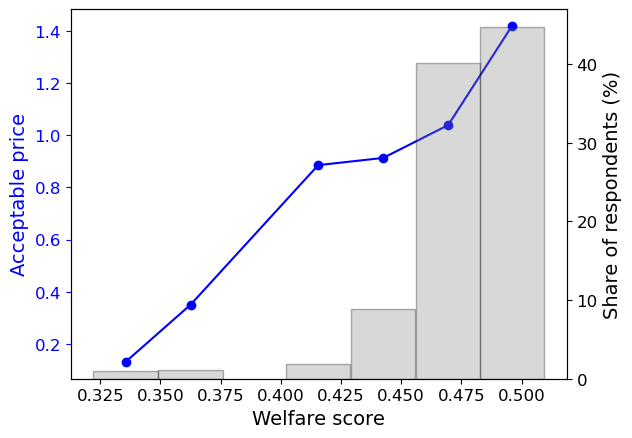

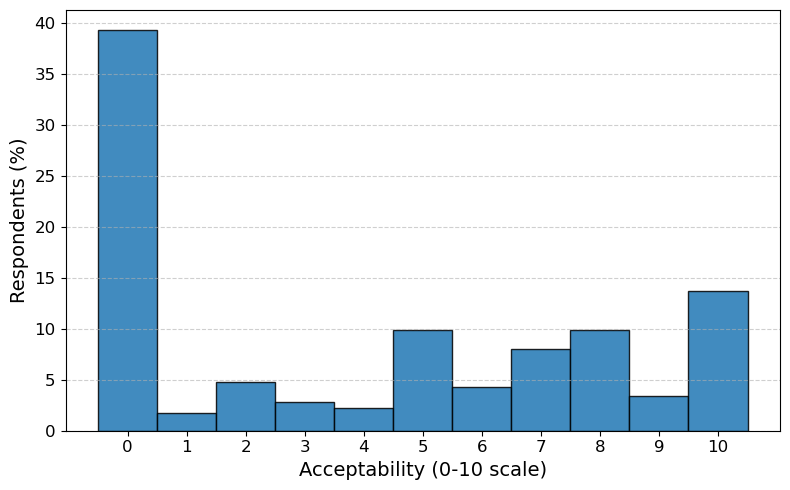

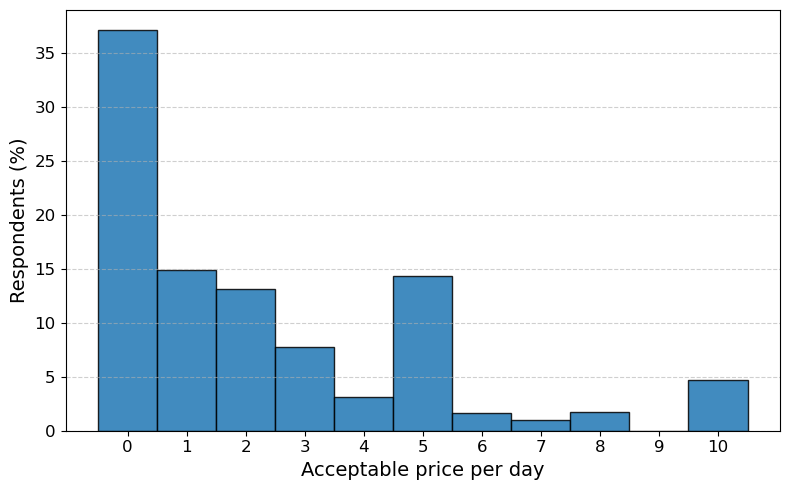

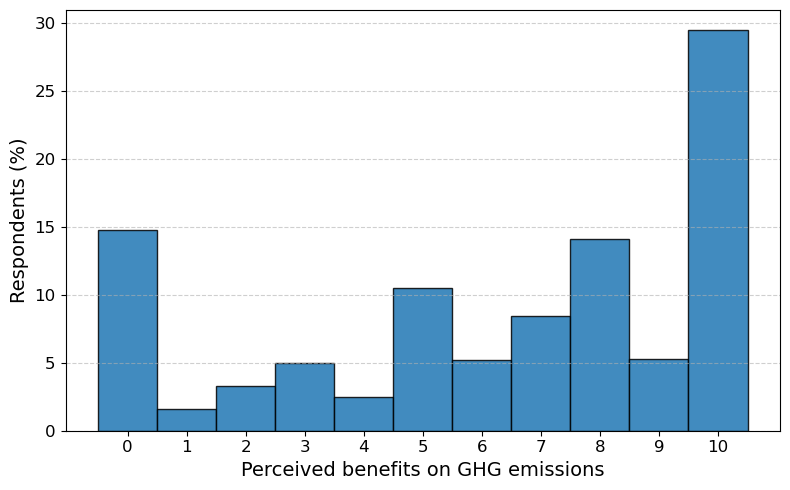

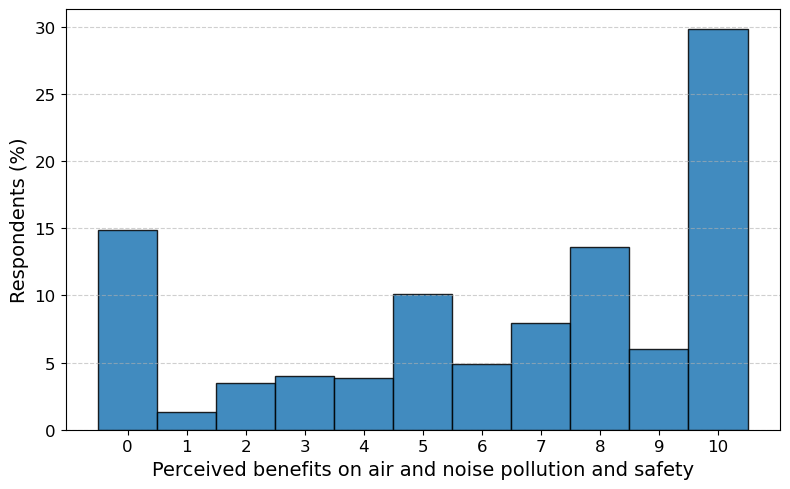

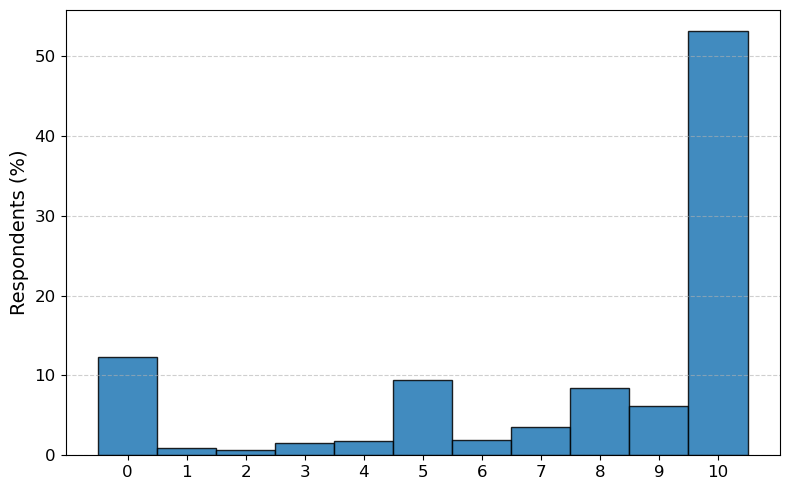

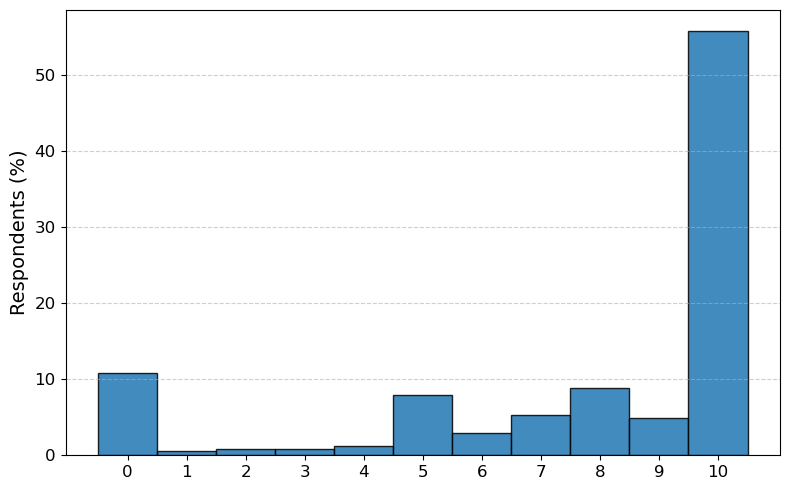

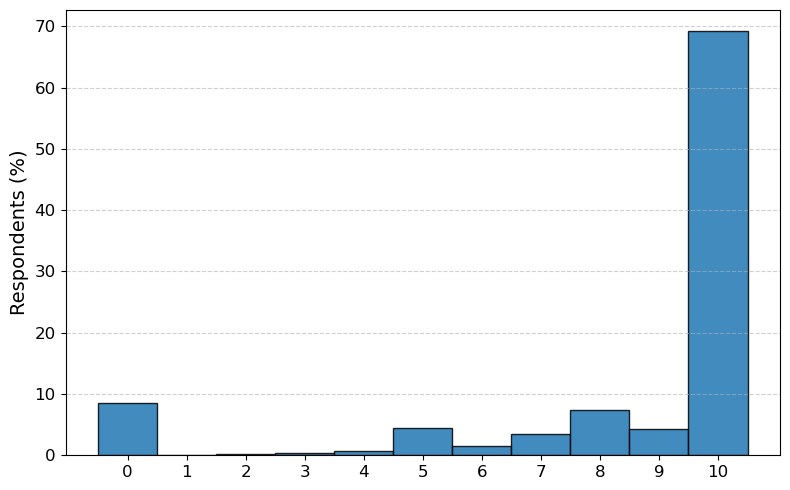

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.410
Model:                            WLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     129.7
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.47e-104
Time:                        09:43:10   Log-Likelihood:                -270.63
No. Observations:                 938   AIC:                             553.3
Df Residuals:                     932   BIC:                             582.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

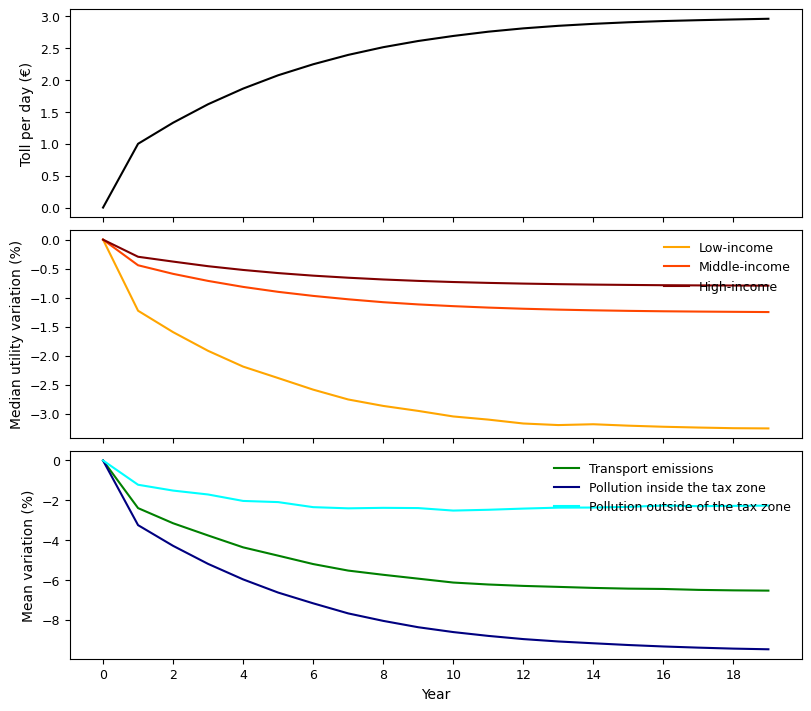

In [ ]:
import numpy as np 
from copy import deepcopy
from scipy.sparse import csr_matrix # type: ignore
import pickle
import datetime

from outcomes import *
from ABM import *
from import_data import * # type: ignore
from calibration import * # type: ignore
from model import * # type: ignore
from plotting_tools import * # type: ignore
from import_transport import *
from policy_support import *

### SCENARIOS

scenario = "baseline"
option_center = "catalunya"

#scenario = "exemption_trips_inside_zone"    #DONE
#scenario = "tax_question_P17"               #DONE
#scenario = "increasing_knowledge"           #DONE
#scenario = "instant_welfare_adjust"         #DONE
#scenario = "discount_low_income"            #DONE
#scenario = "discount_residents"             #DONE

#scenario = "less_expensive_transport"       #DONE
#scenario = "reduce_transport_time"          #DONE

### IMPORT PARAMETERS

path_data = "../data_barcelona/"
option_function = "Cobb-Douglas"

LOGISTIC_PARAM_WELFARE = -0.3
LOGISTIC_PARAM_QOL = 0.3

#Time
year = 0
MAX_YEAR = 20

#Policy impact model
INTEREST_RATE = 0.05
PRICE_TIME = 10 #euros/h - later modulated by income level
WORKING_DAYS = 40 #20 days per month, with 2 trips per day
PRICE_FUEL = 0.11 #euros/km
center = "0801901025"
SOFT_RENT = 10 #50
DIFF_SPEED_CONGESTION = 10


#ABM
SCALE_ABM = 1/100 #Nb of agents in the ABM
PROBA_MOVE = 0.2
INERTIA_OPINION = 0.8 #inertia

#Others
TRANSPORT_EFFICIENCY = 73
TOL_CONGESTION = 3000
TOL_SUBVENTION = 1
TOL_EFFICIENCY = 0.1

### IMPORT DATA

#Import data
gdf = import_data(path_data, center, option = "SECTION") #"DISTRICT" or "SECTION" - Active population: 1.4M
gdf = import_jobs(gdf, path_data)
gdf = import_land_use(gdf, path_data)
gdf = import_ppl_per_hh(gdf, path_data)
gdf = import_rent_and_size(gdf, path_data)
Y_median, gdf = import_income(gdf, path_data)
gdf = import_amenities(gdf, path_data, 0, 0)
employment_centers = gpd.read_file(path_data + "cluster_employment_" + option_center + ".shp")
employment_centers["cluster"] = employment_centers.index
jobs_in_toll_area, houses_in_toll_area, zone_tax = import_tax_zone(gdf, employment_centers)

#Multiple income groups
income_levels = ["LOW", "MED", "HIGH"]
wage_factors = {"LOW": 0.6, "MED": 1.0, "HIGH": 1.4}
pop = {
    "LOW": np.nansum(gdf["pop"] * gdf["share_low_income"] / 100),
    "MED": np.nansum(gdf["pop"] * (100 - gdf["share_high_income"] - gdf["share_low_income"]) / 100),
    "HIGH": np.nansum(gdf["pop"] * gdf["share_high_income"] / 100),
}

#Prepare variables
gdf["size"] = gdf["size_census"]
gdf.loc[gdf["pop"] == 0, "pop"] = 1
gdf.loc[gdf["rent_m2"] == 0, "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["rent_m2"]), "rent_m2"] = np.nanmin(gdf.loc[gdf["rent_m2"]>0, "rent_m2"])
gdf.loc[np.isnan(gdf["size"]), "size"] = np.nansum(gdf.loc[~np.isnan(gdf["size"]), "size"] * gdf.loc[~np.isnan(gdf["size"]), "pop"]) / np.nansum(gdf.loc[~np.isnan(gdf["size"]), "pop"])

#Import transport data
#import_transport_times(gdf, datetime.datetime(2025, 7, 15, 8, 0, 0), path_data, employment_centers, option_center) #datetime.datetime(2025, 7, 15, 8, 0, 0)
travel_time_matrix_car, travel_time_matrix_transit = load_transport_times(gdf, path_data, center, option_center)
travel_time_matrix_car = load_distance_car(travel_time_matrix_car, gdf, employment_centers, zone_tax)
gdf = import_cost_transit(gdf)
travel_time_matrix_transit = travel_time_matrix_transit.merge(gdf[['ID', 'monthly_cost_transit']].rename(columns={'ID': 'from_id'}), on='from_id', how='left')

travel_time_matrix_car["uncongested_speed"] = (travel_time_matrix_car.distance_car / 1000) / (travel_time_matrix_car.travel_time / 60)
travel_time_matrix_car["speed"] = travel_time_matrix_car["uncongested_speed"] - DIFF_SPEED_CONGESTION
travel_time_matrix_car.loc[travel_time_matrix_car["speed"] < 10, "speed"] = 10
travel_time_matrix_car.travel_time = ((travel_time_matrix_car.distance_car / 1000) / travel_time_matrix_car["speed"]) * 60

### CALIBRATION POLICY IMPACT MODEL

#Calibration of B and KAPPA
gdf["land"] = gdf["urb_area"]

mask = ((gdf["rent_m2"] < 19) &(gdf["rent_m2"] > 12)& #7,25
        (gdf["pop"] > 484.0)&
        (~np.isnan(gdf["size"]))
        &(~np.isnan(gdf["pop"]))
        &((gdf["pop"] > 0))
        )

B, KAPPA, SIGMA = calibrate_b_kappa(gdf, mask, INTEREST_RATE, option_function, option_calib = "housing")

#Transport cost calibration
#gdf, FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = compute_cost_car(gdf, Y_median, import_trans_mode, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, travel_time_matrix_car, travel_time_matrix_transit, employment_centers, path_data, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, compute_error_transport)
#with open(path_data + "calib_trans_poly_i_" + option_center + ".pkl", "wb") as f:
#    pickle.dump((FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH), f)
with open(path_data + "calib_trans_poly_i_" + option_center + ".pkl", "rb") as f:
    FIXED_COST_CAR, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH = pickle.load(f)
print("FIXED_COST_CAR: ", FIXED_COST_CAR)
print("LAMBDA: ", LAMBDA)
compute_error_transport([FIXED_COST_CAR, LAMBDA] + list(ARRAY_WAGE_LOW) + list(ARRAY_WAGE_MED) + list(ARRAY_WAGE_HIGH), employment_centers, gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, PRICE_FUEL, jobs_in_toll_area, houses_in_toll_area, income_levels, wage_factors, scenario, Y_median, import_trans_mode, path_data)

#Compute transport cost
gdf, workers_per_cluster, travel_matrix = compute_transport_cost(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, scenario)
print("Modal share of public transport (%):", round(100 * sum(np.nansum(gdf[f"transport_mode_{lvl}"] * gdf[f"pop_{lvl}"]) for lvl in income_levels) / sum(np.nansum(gdf[f"pop_{lvl}"]) for lvl in income_levels)))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf["transport_mode_HIGH"] * gdf["pop_HIGH"])) / (np.nansum(gdf["pop_HIGH"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_MED"] * gdf[f"pop_MED"])) / (np.nansum(gdf[f"pop_MED"]))))
print("Modal share of public transport (%):", round(100 * (np.nansum(gdf[f"transport_mode_LOW"] * gdf[f"pop_LOW"])) / (np.nansum(gdf[f"pop_LOW"]))))
plot_transport_cost(gdf, "_MED")
plot_transport_mode(gdf, "_MED")
plot_employment(gdf, employment_centers, employment_centers['employment'] * 0.0015)

#Calibrate beta and amenities
def compute_log_likelihood(x):
    return calibration_utility_amenity(x, gdf, income_levels, SOFT_RENT, 0, 0)

calib_beta = scipy.optimize.minimize(compute_log_likelihood, [0.44, 183, 256, 434], bounds=[(0.2,0.7), (0,None), (0,None), (0,None)]) #[0.45, 100, 500, 900] #[0.3, 224, 386, 553]
BETA = calib_beta.x[0]
print("BETA:", BETA)
gdf = gdf.drop(columns="amenities", errors="ignore")
amenities = calibration_utility_amenity(calib_beta.x, gdf, income_levels, SOFT_RENT, 1, 1)
gdf = gdf.merge(amenities, on = "ID", how = "left")
gdf.loc[np.isnan(gdf["amenities"]), "amenities"] = 1

# Solve the model
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""
    return sum(compute_error_in_population(u, income_levels, gdf, [pop[lvl] for lvl in income_levels], BETA, B, KAPPA, INTEREST_RATE, option_resid = False)**2)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, calib_beta.x[1:4], bounds=[(0,None), (0,None), (0,None)], method = "Nelder-Mead") #[161, 287, 411] #[219, 329, 471]

if solving_model.success == True:
    R, q, n, w, R_group, q_group, n_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, INTEREST_RATE, income_levels, compute_rents, compute_dwelling_size, option_resid = False)
else:
    raise ValueError("Minimization failed!")

density_residual = np.log(gdf["pop"] / n)
rent_residual = np.log(gdf["rent_m2"] / R)
size_residual = np.log(gdf["size"] / q)

# Plot the result of the calibration
#print_maps(gdf, n, q, R)
plot_line_charts(gdf, n, q, R)

#initial state
def compute_error_in_population_from_utility(u):
    """ Compute error in population associated to utility u"""

    return sum((compute_error_in_population(u, income_levels, gdf, [pop[lvl] for lvl in income_levels], BETA, B, KAPPA, INTEREST_RATE, True, rent_residual, density_residual, size_residual))**2)

solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x, method = "Nelder-Mead") #[159.7, 283.9, 404.7]

if solving_model.success == True:

    R, q, n, w, R_group, q_group, n_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, INTEREST_RATE, income_levels, compute_rents, compute_dwelling_size, option_resid = True, resid_rent = rent_residual, resid_density = density_residual, resid_size = size_residual)

else:
    raise ValueError("Minimization failed!")

plot_line_charts(gdf, n, q, R)
compare_shares_in_tax_zone(gdf, n_group, houses_in_toll_area)

# ABM: translate outputs at the household level
N = {lvl: round(pop[lvl] * SCALE_ABM) for lvl in income_levels}
indiv_loc_matrix = {
    lvl: compute_indiv_loc_matrix(
        N[lvl], len(gdf), (n_group[lvl] * SCALE_ABM).to_numpy()
    )
    for lvl in income_levels
}

rent_indiv = {lvl: indiv_loc_matrix[lvl] @ R.to_numpy() for lvl in income_levels} #R_group[lvl]
dwelling_size_indiv = {lvl: indiv_loc_matrix[lvl] @ q.to_numpy() for lvl in income_levels} #q_group[lvl]

utility = {}

for lvl in income_levels:
    u = compute_utility_manually(
        indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
        indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
        dwelling_size_indiv[lvl],
        rent_indiv[lvl],
        BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
    )
    u[np.isnan(u)] = 0
    utility[lvl] = u

housing_indiv = {
    lvl: dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    for lvl in income_levels
}

# Save outputs
save_housing = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}
save_rent = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_dwelling_size = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_transport_mode = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_utility = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_population = np.zeros((len(gdf), MAX_YEAR))
save_population[:, 0] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
save_population_lvl = {lvl: np.zeros((len(gdf), MAX_YEAR)) for lvl in income_levels}

for lvl in income_levels:
    save_housing[lvl][:, 0] = deepcopy(housing_indiv[lvl])
    save_rent[lvl][:, 0] = deepcopy(rent_indiv[lvl])
    save_dwelling_size[lvl][:, 0] = deepcopy(dwelling_size_indiv[lvl])
    save_transport_mode[lvl][:, 0] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
    save_utility[lvl][:, 0] = deepcopy(utility[lvl])
    save_population_lvl[lvl][:, 0] = np.nansum(indiv_loc_matrix[lvl], 0)

save_tax = np.zeros(MAX_YEAR)
save_tax[0] = 0
save_emissions = np.zeros(MAX_YEAR)
save_score_welfare = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_qol = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_score_congestion = {lvl: np.zeros((N[lvl], MAX_YEAR)) for lvl in income_levels}
save_median_support = np.zeros(MAX_YEAR)
qol_in_zone = np.zeros(MAX_YEAR)
qol_out_zone = np.zeros(MAX_YEAR)
vkm_in_zone = np.zeros(MAX_YEAR)
vkm_out_zone = np.zeros(MAX_YEAR)
total_vkm = np.zeros(MAX_YEAR)
total_vkm_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_in_zone_lvl = np.empty(MAX_YEAR, dtype=object)
vkm_out_zone_lvl = np.empty(MAX_YEAR, dtype=object)
mode_shares_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_in_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_vkm_out_zone_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_in_toll_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_in_toll_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
live_out_and_work_out_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_wage_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_tcost_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_rent_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
avg_dsize_lvl = {lvl: np.full(MAX_YEAR, np.nan) for lvl in income_levels}
tax_revenues = np.zeros(MAX_YEAR)

save_emissions[0], total_vkm[0], tax_revenues[0], _, _, total_vkm_lvl[0] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, 0, WORKING_DAYS, 0, SCALE_ABM)
qol_in_zone[0], qol_out_zone[0], vkm_in_zone[0], vkm_out_zone[0], vkm_in_zone_lvl[0], vkm_out_zone_lvl[0] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)
BETA_CONG = DIFF_SPEED_CONGESTION/total_vkm[0]

### DECOMPOSITION TRANSPORT

gdf["live_in_toll"] = (gdf.ID.isin(houses_in_toll_area))
mask_zone = gdf.ID.isin(houses_in_toll_area).to_numpy()
mask_out = ~gdf.ID.isin(houses_in_toll_area).to_numpy()

for lvl in income_levels:
    s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
    gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

for lvl in income_levels:
    #mode share
    mode_shares_lvl[lvl][0] = np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, 0]) / np.nansum(save_population_lvl[lvl][:, 0])
    #distances
    avg_vkm_lvl[lvl][0] = (total_vkm_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, 0])))
    avg_vkm_in_zone_lvl[lvl][0] = vkm_in_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, 0]))
    avg_vkm_out_zone_lvl[lvl][0] = vkm_out_zone_lvl[0][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, 0]))
    #repartition
    gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
    gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
    gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
    live_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
    live_out_and_work_in_toll_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
    live_in_toll_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
    live_out_and_work_out_lvl[lvl][0] = np.nansum(save_population_lvl[lvl][:,0] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
    #decompo util
    avg_wage_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
    avg_tcost_lvl[lvl][0] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
    avg_rent_lvl[lvl][0] = np.nanmean(rent_indiv[lvl])
    avg_dsize_lvl[lvl][0] = np.nanmean(dwelling_size_indiv[lvl])

### FIRST SIMULATION TO COMPUTE UTILITY LOSSES

gdf_init, _, _ = compute_transport_cost(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0, income_levels, wage_factors, "baseline", 0, 0)
 
utility_init = {lvl: compute_utility_manually(gdf_init[f"wage_{lvl}"],
                                              gdf_init[f"transport_cost_{lvl}"],
                                              q, 
                                              R, 
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

gdf_tax, _, _ = compute_transport_cost(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, 0.5, income_levels, wage_factors, "baseline", 0, 0)
 
utility_tax = {lvl: compute_utility_manually(gdf_tax[f"wage_{lvl}"],
                                              gdf_tax[f"transport_cost_{lvl}"],
                                              q,
                                              R,
                                              BETA, gdf["amenities"]
                                              ) for lvl in income_levels}

#utility_init["LOW"][utility_init["LOW"] < 140] = np.nan

for lvl in income_levels:
    gdf[f"score_welfare_{lvl.lower()}"] = compute_score(compute_change_in_welfare(utility_init[lvl], utility_tax[lvl]), LOGISTIC_PARAM_WELFARE)

expected_welfare_loss = gdf[["ID", "geometry"] + [f"score_welfare_{lvl.lower()}" for lvl in income_levels]]

### CALIBRATION POLICY SUPPORT

BETA_OPINION, BETA_PRICE, INITIAL_OPINION, INITIAL_PRICE, INITIAL_CC, INITIAL_WELFARE, INITIAL_QOL, INITIAL_KNOWLEDGE = import_opinion_parameters(path_data, scenario, expected_welfare_loss, weighted_median, Y_median, wage_factors)

tax = INITIAL_PRICE
acceptable_price = {"LOW": INITIAL_PRICE, "MED": INITIAL_PRICE, "HIGH": INITIAL_PRICE}
#support = {"LOW": INITIAL_OPINION, "MED": INITIAL_OPINION, "HIGH": INITIAL_OPINION}
save_score_emissions = np.zeros(MAX_YEAR)
save_score_emissions[0] = INITIAL_CC
save_knowledge = np.zeros(MAX_YEAR)
save_knowledge[0] = INITIAL_KNOWLEDGE
score_qol = {"LOW": INITIAL_QOL, "MED": INITIAL_QOL, "HIGH": INITIAL_QOL}
score_welfare = {"LOW": INITIAL_WELFARE, "MED": INITIAL_WELFARE, "HIGH": INITIAL_WELFARE}
support = {lvl: INITIAL_OPINION * np.ones(N[lvl]) for lvl in income_levels}

year = year + 1
#plot_distance_distrib_check(income_levels, travel_matrix, "HIGH")

tax_revenue_here = 137000000
subvention_here = 137000000
efficiency = 0
discount = 12.79346
time_discount = 0

while year < MAX_YEAR:

    print("YEAR", year)

    save_knowledge[year] = save_knowledge[year-1] + 0.02

    # Urban form with the tax, without inertia
    
    TRIP_TO_ZONE_OUTPUT = total_vkm[year - 1]
    TRIP_TO_ZONE_INPUT = 0
    index_q = 0

    condition = True

    while condition == True:

        if scenario == "less_expensive_transport":
            discount = discount - (subvention_here-tax_revenue_here)/10000000
            time_discount = 0
        elif scenario == "reduce_transport_time":
            time_discount = time_discount + ((efficiency - TRANSPORT_EFFICIENCY) / 5000)
            discount = 0
        else:
            discount = 0
            time_discount = 0
        
        TRIP_TO_ZONE_INPUT = TRIP_TO_ZONE_OUTPUT.copy()
        index_q = index_q + 1
        travel_time_matrix_car["speed"] = travel_time_matrix_car["uncongested_speed"] - BETA_CONG * TRIP_TO_ZONE_INPUT
        travel_time_matrix_car.loc[travel_time_matrix_car["speed"] < 10, "speed"] = 10
        travel_time_matrix_car.travel_time = ((travel_time_matrix_car.distance_car / 1000) / travel_time_matrix_car["speed"]) * 60

        gdf, workers_per_cluster, travel_matrix = compute_transport_cost(gdf, travel_time_matrix_car, travel_time_matrix_transit, PRICE_TIME, WORKING_DAYS, FIXED_COST_CAR, PRICE_FUEL, LAMBDA, ARRAY_WAGE_LOW, ARRAY_WAGE_MED, ARRAY_WAGE_HIGH, jobs_in_toll_area, houses_in_toll_area, tax, income_levels, wage_factors, scenario, discount, time_discount)

        def compute_error_in_population_from_utility(u):
            """ Compute error in population associated to utility u"""

            error_population = sum((compute_error_in_population(u, income_levels, gdf, [pop[lvl] for lvl in income_levels], BETA, B, KAPPA, INTEREST_RATE, True, rent_residual, density_residual, size_residual)) ** 2)
            return error_population

        solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x, method = "Nelder-Mead")

        if solving_model.message == 'Maximum number of function evaluations has been exceeded.':
            solving_model = scipy.optimize.minimize(compute_error_in_population_from_utility, solving_model.x, method = "Nelder-Mead")

        if solving_model.success == True:

            R, q, n, w, R_group, q_group, n_group = compute_outcomes(solving_model.x, gdf, BETA, B, KAPPA, INTEREST_RATE, income_levels, compute_rents, compute_dwelling_size, option_housing_supply = False, option_resid = True, resid_rent = rent_residual, resid_density = density_residual, resid_size = size_residual)

        else:
            raise ValueError("Minimization failed!")

        housing_without_inertia = n * q

        # AMB
        has_moved = {}
        indiv_loc_matrix_new = {}

        for lvl in income_levels:
            
            proba_from, proba_to = compute_proba_of_moving(
                np.nansum(indiv_loc_matrix[lvl], 0), #save_housing[lvl][:, year - 1],
                (n_group[lvl] * SCALE_ABM).to_numpy() #(n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
                )

            
            indiv_loc_matrix_new[lvl] = deepcopy(indiv_loc_matrix[lvl])
    
            indiv_loc_matrix_new[lvl], has_moved[lvl] = make_people_move(
                indiv_loc_matrix_new[lvl],
                N[lvl],
                len(gdf),
                indiv_loc_matrix[lvl],
                proba_from,
                proba_to,
                PROBA_MOVE
                )
        
        _, TRIP_TO_ZONE_OUTPUT, tax_revenue_here, subvention_here, commuters_transit, _ = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, tax, WORKING_DAYS, discount, SCALE_ABM)

        efficiency = - time_discount * commuters_transit / (tax_revenue_here / 1000000)

        if scenario == "less_expensive_transport":
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > TOL_CONGESTION) | (np.abs(subvention_here - tax_revenue_here)> TOL_SUBVENTION)
        elif scenario == "reduce_transport_time":
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > TOL_CONGESTION) | (np.abs(efficiency - TRANSPORT_EFFICIENCY)> TOL_EFFICIENCY)
        else:
            print("(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT)", (TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT))
            condition = (np.abs(TRIP_TO_ZONE_INPUT- TRIP_TO_ZONE_OUTPUT) > TOL_CONGESTION)
    

    # AMB
    has_moved = {}
    indiv_loc_matrix_new = {}

    for lvl in income_levels:
        
        proba_from, proba_to = compute_proba_of_moving(
                np.nansum(indiv_loc_matrix[lvl], 0), #save_housing[lvl][:, year - 1],
                (n_group[lvl] * SCALE_ABM).to_numpy() #(n_group[lvl] * q_group[lvl] * SCALE_ABM).to_numpy()
                )
        
    
        indiv_loc_matrix_new[lvl] = deepcopy(indiv_loc_matrix[lvl])
    
        indiv_loc_matrix[lvl], has_moved[lvl] = make_people_move(
            indiv_loc_matrix_new[lvl],
            N[lvl],
            len(gdf),
            indiv_loc_matrix[lvl],
            proba_from,
            proba_to,
            PROBA_MOVE
            )
    
    rent_indiv_new = {lvl: indiv_loc_matrix[lvl] @ R.to_numpy() for lvl in income_levels} #R_group[lvl]
    dwelling_size_indiv_new = {lvl: indiv_loc_matrix[lvl] @ q.to_numpy() for lvl in income_levels} #q

    for lvl in income_levels:
        # Update rents and dwelling sizes for movers
        mask_moved = has_moved[lvl] == 1
        rent_indiv[lvl][mask_moved] = rent_indiv_new[lvl][mask_moved]
        dwelling_size_indiv[lvl][mask_moved] = dwelling_size_indiv_new[lvl][mask_moved]

        # Compute utility
        utility[lvl] = compute_utility_manually(
            indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"],
            indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"],
            dwelling_size_indiv[lvl],
            rent_indiv[lvl],
            BETA, indiv_loc_matrix[lvl] @ gdf["amenities"]
        )
    
        utility[lvl][np.isnan(utility[lvl])] = 0

        # Compute individual housing
        housing_indiv[lvl] = dwelling_size_indiv[lvl] @ csr_matrix(indiv_loc_matrix[lvl])
    
    #Save outputs
    save_population[:, year] = np.sum([np.nansum(indiv_loc_matrix[lvl], 0) for lvl in income_levels], axis=0)
    save_tax[year] = tax

    for lvl in income_levels:
        save_population_lvl[lvl][:, year] = np.nansum(indiv_loc_matrix[lvl], 0)
        save_housing[lvl][:, year] = deepcopy(housing_indiv[lvl])
        save_rent[lvl][:, year] = deepcopy(rent_indiv[lvl])
        save_dwelling_size[lvl][:, year] = deepcopy(dwelling_size_indiv[lvl])
        save_transport_mode[lvl][:, year] = deepcopy(indiv_loc_matrix[lvl] @ gdf[f"transport_mode_{lvl}"])
        save_utility[lvl][:, year] = deepcopy(utility[lvl])

    # Policy support
    score_welfare = {lvl: compute_score(compute_change_in_welfare(save_utility[lvl][:, 0], save_utility[lvl][:, year]), LOGISTIC_PARAM_WELFARE)
                 for lvl in income_levels}
    
    save_emissions[year], total_vkm[year], tax_revenues[year], _, _, total_vkm_lvl[year] = compute_emissions(gdf, travel_matrix, indiv_loc_matrix, income_levels, jobs_in_toll_area, houses_in_toll_area, tax, WORKING_DAYS, discount, SCALE_ABM)

    qol_in_zone[year], qol_out_zone[year], vkm_in_zone[year], vkm_out_zone[year], vkm_in_zone_lvl[year], vkm_out_zone_lvl[year] = compute_qol_congestion(gdf, travel_matrix, indiv_loc_matrix, income_levels)


    ### DECOMPOSITION TRANSPORT

    gdf = gdf.drop(columns = ["work_in_toll_LOW", "work_in_toll_MED", "work_in_toll_HIGH"])
    for lvl in income_levels:
        s = (travel_matrix.loc[travel_matrix.to_id.isin(jobs_in_toll_area),
                      ["from_id", f"proba_center_{lvl}"]].groupby("from_id")[f"proba_center_{lvl}"].sum())
        gdf = gdf.merge(s, left_on="ID", right_on="from_id", how="left").rename(columns={f"proba_center_{lvl}": f"work_in_toll_{lvl}"}).fillna(0)

    for lvl in income_levels:
        #mode share
        mode_shares_lvl[lvl][year] = np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, year]) / np.nansum(save_population_lvl[lvl][:, year])
        #distances
        avg_vkm_lvl[lvl][year] = (total_vkm_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, year])))
        avg_vkm_in_zone_lvl[lvl][year] = vkm_in_zone_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, year]))
        avg_vkm_out_zone_lvl[lvl][year] = vkm_out_zone_lvl[year][lvl] / (np.nansum(gdf[f"transport_mode_{lvl}"] * save_population_lvl[lvl][:, year]))
        #repartition
        gdf[f"live_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == True) * gdf[f"work_in_toll_{lvl}"]
        gdf[f"live_out_and_work_in_toll_{lvl}"] = (gdf["live_in_toll"] == False) * gdf[f"work_in_toll_{lvl}"]
        gdf[f"live_in_toll_and_work_out_{lvl}"] = (gdf["live_in_toll"] == True) * (1 - gdf[f"work_in_toll_{lvl}"])
        gdf[f"live_out_and_work_out_toll_{lvl}"] = (gdf["live_in_toll"] == False) * (1 - gdf[f"work_in_toll_{lvl}"])
        live_and_work_in_toll_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_and_work_in_toll_{lvl}"]) / N[lvl]
        live_out_and_work_in_toll_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_out_and_work_in_toll_{lvl}"]) / N[lvl]
        live_in_toll_and_work_out_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_in_toll_and_work_out_{lvl}"]) / N[lvl]
        live_out_and_work_out_lvl[lvl][year] = np.nansum(save_population_lvl[lvl][:,year] * gdf[f"live_out_and_work_out_toll_{lvl}"]) / N[lvl]
        #decompo util
        avg_wage_lvl[lvl][year] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"wage_{lvl}"])
        avg_tcost_lvl[lvl][year] = np.nanmean(indiv_loc_matrix[lvl] @ gdf[f"transport_cost_{lvl}"])
        avg_rent_lvl[lvl][year] = np.nanmean(rent_indiv[lvl])
        avg_dsize_lvl[lvl][year] = np.nanmean(dwelling_size_indiv[lvl])

    save_score_emissions[year] = compute_score(compute_relative_change(save_emissions[0], save_emissions[year]), LOGISTIC_PARAM_QOL)
    
    score_qol_zone = compute_score(compute_relative_change(qol_in_zone[0], qol_in_zone[year]), LOGISTIC_PARAM_QOL)
    score_qol_out = compute_score(compute_relative_change(qol_out_zone[0], qol_out_zone[year]), LOGISTIC_PARAM_QOL)
    
    
    political_opinion = {}
    price_here = {}
    acceptable_price_new = {}

    for lvl in income_levels:
        # QOL score        
        if scenario == "instant_welfare_adjust":
            new_score_qol = (indiv_loc_matrix[lvl] @ mask_zone) * score_qol_zone + (indiv_loc_matrix[lvl] @ mask_out) * score_qol_out
            score_qol[lvl] = (INERTIA_OPINION * score_qol[lvl]) + ((1 - INERTIA_OPINION) * new_score_qol) 
        else:
            score_qol[lvl] = (indiv_loc_matrix[lvl] @ mask_zone) * score_qol_zone + (indiv_loc_matrix[lvl] @ mask_out) * score_qol_out

        # Political opinion and price
        political_opinion[lvl] = compute_opinion(score_welfare[lvl], score_qol[lvl],
                                                       save_score_emissions[year], BETA_OPINION, scenario, lvl, save_knowledge[year])
        
        price_here[lvl] = compute_opinion(score_welfare[lvl], score_qol[lvl], save_score_emissions[year], BETA_PRICE, scenario, lvl, save_knowledge[year])
        price_here[lvl][price_here[lvl] < 0] = 0

        if scenario == "instant_welfare_adjust":
            support[lvl] = political_opinion[lvl]
            acceptable_price[lvl] = price_here[lvl]
        else:
            support[lvl] = (INERTIA_OPINION * support[lvl]) + ((1 - INERTIA_OPINION) * political_opinion[lvl])
            acceptable_price[lvl] = (INERTIA_OPINION * acceptable_price[lvl]) + ((1 - INERTIA_OPINION) * price_here[lvl])

        # Save scores
        save_score_welfare[lvl][:, year] = score_welfare[lvl]
        save_score_qol[lvl][:, year] = score_qol[lvl]

    save_median_support[year] = np.nanmedian(np.concatenate([support[lvl] for lvl in income_levels]))

    #Policy update
    tax = np.nanmedian(np.concatenate([acceptable_price[lvl] for lvl in income_levels]))
    #tax = np.fmin(tax * 1.05, np.nanmedian(acceptable_price))

    year = year + 1


emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high = relative_change_outputs(save_emissions, qol_in_zone, qol_out_zone, save_utility, compute_relative_change, compute_change_in_welfare, MAX_YEAR)

#Main results plot
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
scenario

'baseline'

In [ ]:
def main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high):
    
    # --- Global formatting for academic figures ---
    mpl.rcParams['font.size'] = 10
    mpl.rcParams['axes.labelsize'] = 10
    mpl.rcParams['xtick.labelsize'] = 9
    mpl.rcParams['ytick.labelsize'] = 9
    mpl.rcParams['legend.fontsize'] = 9

    _, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
    years = range(len(save_tax))

    # --- Panel 1 ---
    axes[0].plot(years, 2 * save_tax, color="black", linewidth=1.5)
    axes[0].set_ylabel('Toll per day (€)')

    # --- Panel 2 ---
    axes[1].plot(years, utility_change_low,  label="Low-income",    color="orange", linewidth=1.5)
    axes[1].plot(years, utility_change_med,  label="Middle-income", color="orangered",  linewidth=1.5)
    axes[1].plot(years, utility_change_high, label="High-income",   color="maroon",    linewidth=1.5)
    axes[1].set_ylabel("Median utility variation (%)")
    axes[1].legend(frameon=False, loc="upper center", fontsize=9)

    # --- Panel 3 ---
    axes[2].plot(years, emission_change,        label="Transport emissions", color="green", linewidth=1.5)
    axes[2].plot(years, change_qol_in_zone,     label="Pollution inside the tax zone",         color="navy",   linewidth=1.5)
    axes[2].plot(years, change_qol_out_zone,    label="Pollution outside of the tax zone",    color="cyan", linewidth=1.5)
    axes[2].set_ylabel("Mean variation (%)")
    axes[2].legend(frameon=False, loc="upper right", fontsize=9)
    axes[-1].set_xlabel("Year")
    axes[-1].set_xticks(list(years)[::2])   # every 2 years

    #fig.tight_layout()
    plt.show()

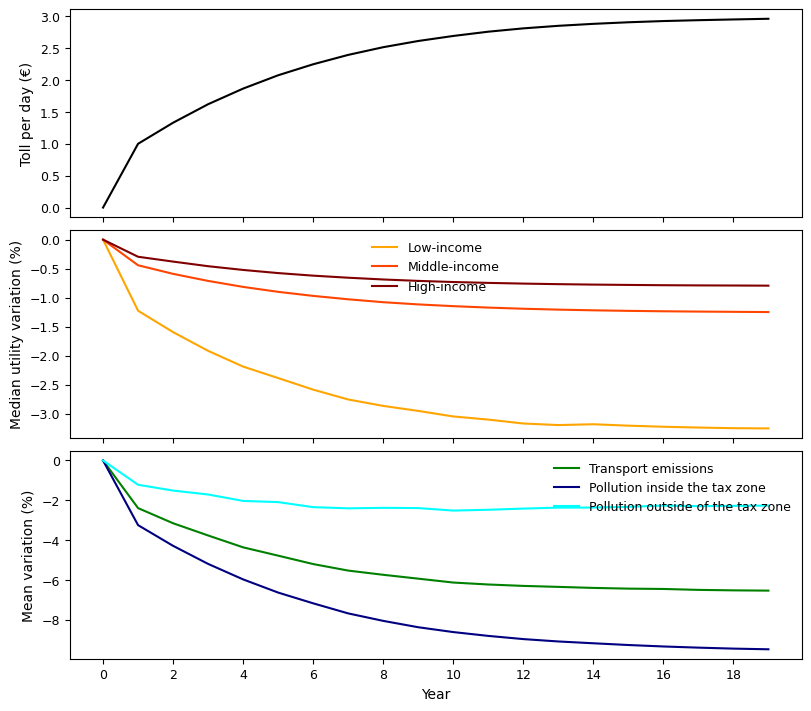

In [ ]:
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
def main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high):
    
    # --- Global formatting for academic figures ---
    mpl.rcParams['font.size'] = 10
    mpl.rcParams['axes.labelsize'] = 10
    mpl.rcParams['xtick.labelsize'] = 9
    mpl.rcParams['ytick.labelsize'] = 9
    mpl.rcParams['legend.fontsize'] = 9

    _, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
    years = range(len(save_tax))

    # --- Panel 1 ---
    axes[0].plot(years, 2 * save_tax, color="black", linewidth=1.5)
    axes[0].set_ylabel('Toll per day (€)')

    # --- Panel 2 ---
    axes[1].plot(years, utility_change_low,  label="Low-income",    color="orange", linewidth=1.5)
    axes[1].plot(years, utility_change_med,  label="Middle-income", color="orangered",  linewidth=1.5)
    axes[1].plot(years, utility_change_high, label="High-income",   color="maroon",    linewidth=1.5)
    axes[1].set_ylabel("Median utility variation (%)")
    axes[1].legend(frameon=False, loc="middle right", fontsize=9)

    # --- Panel 3 ---
    axes[2].plot(years, emission_change,        label="Transport emissions", color="green", linewidth=1.5)
    axes[2].plot(years, change_qol_in_zone,     label="Pollution inside the tax zone",         color="navy",   linewidth=1.5)
    axes[2].plot(years, change_qol_out_zone,    label="Pollution outside of the tax zone",    color="cyan", linewidth=1.5)
    axes[2].set_ylabel("Mean variation (%)")
    axes[2].legend(frameon=False, loc="upper right", fontsize=9)
    axes[-1].set_xlabel("Year")
    axes[-1].set_xticks(list(years)[::2])   # every 2 years

    #fig.tight_layout()
    plt.show()

ValueError: 'middle right' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

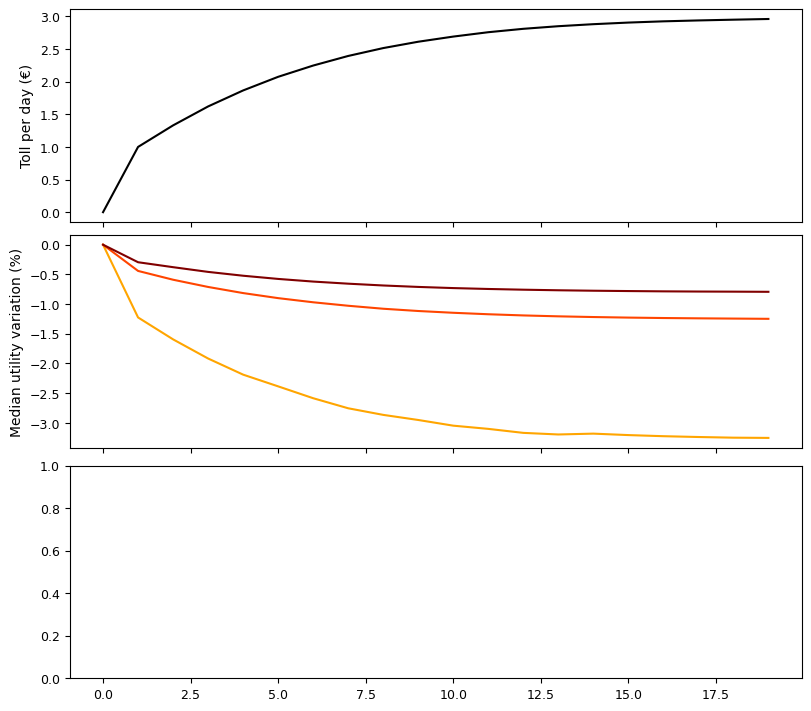

In [ ]:
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
def main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high):
    
    # --- Global formatting for academic figures ---
    mpl.rcParams['font.size'] = 10
    mpl.rcParams['axes.labelsize'] = 10
    mpl.rcParams['xtick.labelsize'] = 9
    mpl.rcParams['ytick.labelsize'] = 9
    mpl.rcParams['legend.fontsize'] = 9

    _, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
    years = range(len(save_tax))

    # --- Panel 1 ---
    axes[0].plot(years, 2 * save_tax, color="black", linewidth=1.5)
    axes[0].set_ylabel('Toll per day (€)')

    # --- Panel 2 ---
    axes[1].plot(years, utility_change_low,  label="Low-income",    color="orange", linewidth=1.5)
    axes[1].plot(years, utility_change_med,  label="Middle-income", color="orangered",  linewidth=1.5)
    axes[1].plot(years, utility_change_high, label="High-income",   color="maroon",    linewidth=1.5)
    axes[1].set_ylabel("Median utility variation (%)")
    axes[1].legend(frameon=False, loc="center right", fontsize=9)

    # --- Panel 3 ---
    axes[2].plot(years, emission_change,        label="Transport emissions", color="green", linewidth=1.5)
    axes[2].plot(years, change_qol_in_zone,     label="Pollution inside the tax zone",         color="navy",   linewidth=1.5)
    axes[2].plot(years, change_qol_out_zone,    label="Pollution outside of the tax zone",    color="cyan", linewidth=1.5)
    axes[2].set_ylabel("Mean variation (%)")
    axes[2].legend(frameon=False, loc="upper right", fontsize=9)
    axes[-1].set_xlabel("Year")
    axes[-1].set_xticks(list(years)[::2])   # every 2 years

    #fig.tight_layout()
    plt.show()

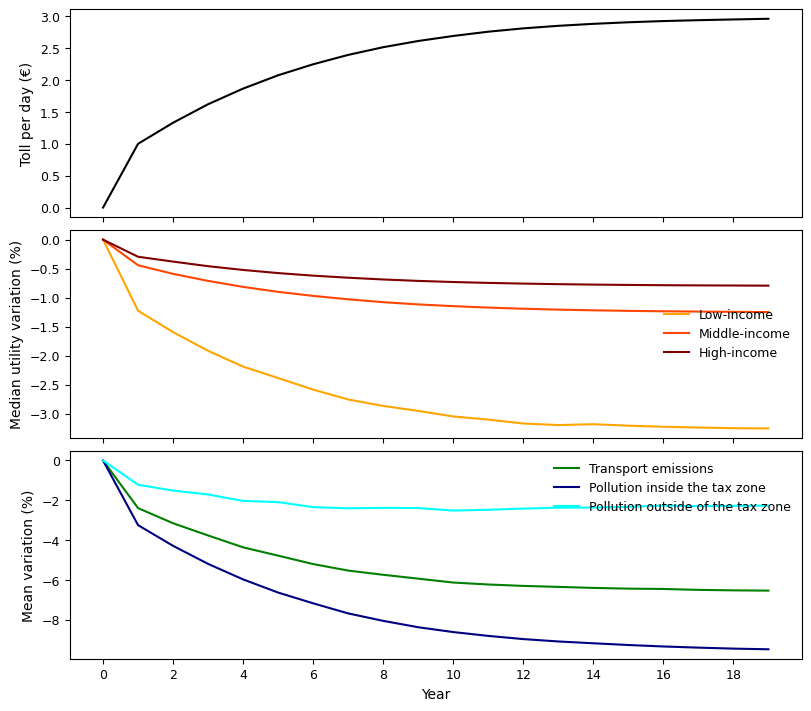

In [ ]:
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
def main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high):
    
    # --- Global formatting for academic figures ---
    mpl.rcParams['font.size'] = 10
    mpl.rcParams['axes.labelsize'] = 10
    mpl.rcParams['xtick.labelsize'] = 9
    mpl.rcParams['ytick.labelsize'] = 9
    mpl.rcParams['legend.fontsize'] = 9

    _, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
    years = range(len(save_tax))

    # --- Panel 1 ---
    axes[0].plot(years, 2 * save_tax, color="black", linewidth=1.5)
    axes[0].set_ylabel('Toll per day (€)')

    # --- Panel 2 ---
    axes[1].plot(years, utility_change_low,  label="Low-income",    color="orange", linewidth=1.5)
    axes[1].plot(years, utility_change_med,  label="Middle-income", color="orangered",  linewidth=1.5)
    axes[1].plot(years, utility_change_high, label="High-income",   color="maroon",    linewidth=1.5)
    axes[1].set_ylabel("Median utility variation (%)")
    axes[1].legend(frameon=False, loc="lower right", fontsize=9)

    # --- Panel 3 ---
    axes[2].plot(years, emission_change,        label="Transport emissions", color="green", linewidth=1.5)
    axes[2].plot(years, change_qol_in_zone,     label="Pollution inside the tax zone",         color="navy",   linewidth=1.5)
    axes[2].plot(years, change_qol_out_zone,    label="Pollution outside of the tax zone",    color="cyan", linewidth=1.5)
    axes[2].set_ylabel("Mean variation (%)")
    axes[2].legend(frameon=False, loc="upper right", fontsize=9)
    axes[-1].set_xlabel("Year")
    axes[-1].set_xticks(list(years)[::2])   # every 2 years

    #fig.tight_layout()
    plt.show()

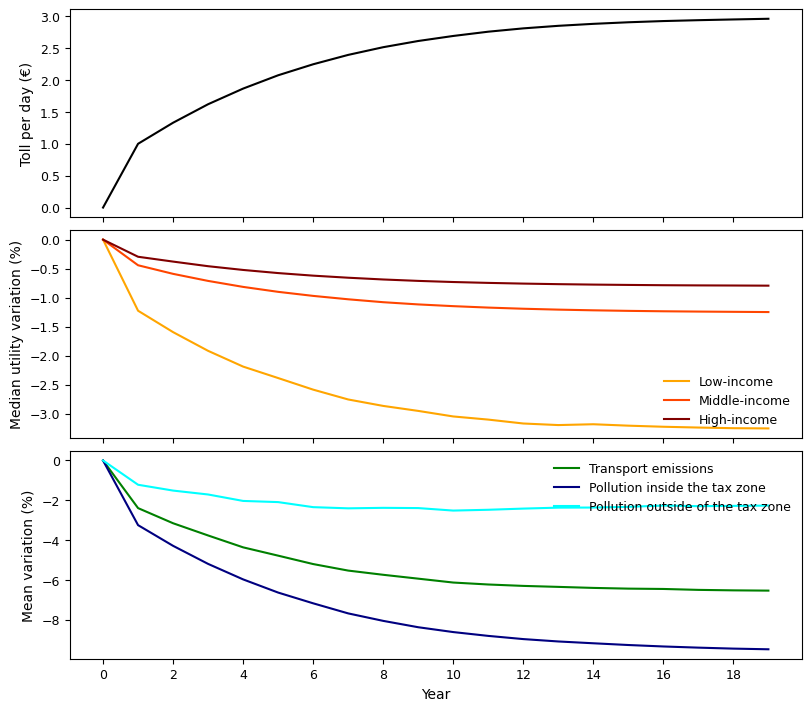

In [ ]:
main_plot(save_tax, emission_change, change_qol_in_zone, change_qol_out_zone, utility_change_low, utility_change_med, utility_change_high)

In [ ]:
save_tax

array([0.        , 0.5       , 0.66513454, 0.81018065, 0.93273988,
       1.0371408 , 1.12340164, 1.19689637, 1.25724976, 1.30592673,
       1.34534757, 1.37885311, 1.40487758, 1.42486334, 1.44036037,
       1.45271427, 1.46218975, 1.46909753, 1.47486374, 1.48012968])

In [ ]:
save_tax * 2

array([0.        , 1.        , 1.33026909, 1.62036129, 1.86547976,
       2.07428159, 2.24680328, 2.39379274, 2.51449953, 2.61185346,
       2.69069513, 2.75770622, 2.80975516, 2.84972668, 2.88072073,
       2.90542853, 2.92437949, 2.93819506, 2.94972748, 2.96025937])

In [ ]:
emission_change

array([ 0.        , -2.39261654, -3.15360332, -3.76780947, -4.36457455,
       -4.78204612, -5.20437101, -5.53240712, -5.74370538, -5.93793806,
       -6.13339806, -6.23143338, -6.30210454, -6.3514115 , -6.40293648,
       -6.43935183, -6.45602003, -6.50199678, -6.52559707, -6.5391799 ])

In [ ]:
change_qol_in_zone

array([ 0.        , -3.24853565, -4.28861116, -5.19623631, -5.97515146,
       -6.63717026, -7.17719729, -7.68371028, -8.0594626 , -8.37916407,
       -8.62223178, -8.81436858, -8.97481973, -9.09434079, -9.18525818,
       -9.27280884, -9.3459075 , -9.40456534, -9.4536565 , -9.48728196])

In [ ]:
change_qol_out_zone

array([ 0.        , -1.21913951, -1.51184179, -1.70822039, -2.03214334,
       -2.09058687, -2.34466188, -2.40376298, -2.37936833, -2.39116391,
       -2.51681156, -2.47639149, -2.41729661, -2.36927496, -2.36424429,
       -2.32938862, -2.26392872, -2.2954038 , -2.28050974, -2.26611925])

In [ ]:
def append_scenario_to_excel(filename, scenario_name,
                             tax_level, emission_change,
                             change_qol_in_zone, change_qol_out_zone,
                             utility_change_low, utility_change_med, utility_change_high):

    # Put variables into a dict
    data = {
        "tax_level": tax_level,
        "emission_change": emission_change,
        "change_qol_in_zone": change_qol_in_zone,
        "change_qol_out_zone": change_qol_out_zone,
        "utility_change_low": utility_change_low,
        "utility_change_med": utility_change_med,
        "utility_change_high": utility_change_high,
    }

    # Convert to DataFrame (7 rows, 20 columns)
    df = pd.DataFrame(data).T
    df.columns = [f"t{t}" for t in range(1, len(tax_level)+1)]
    df.insert(0, "scenario", scenario_name)

    # Append blank row after each scenario
    df_blank = pd.DataFrame([[""] + [""]*len(tax_level)], columns=df.columns)

    # Write or append
    if not os.path.exists(filename):
        # First write
        with pd.ExcelWriter(filename, engine="openpyxl") as writer:
            df.to_excel(writer, index=True)
            df_blank.to_excel(writer, index=False, header=False, startrow=len(df)+1)
    else:
        # Append
        wb = load_workbook(filename)
        ws = wb.active
        startrow = ws.max_row + 1

        with pd.ExcelWriter(filename, engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
            df.to_excel(writer, index=True, header=False, startrow=startrow)
            df_blank.to_excel(writer, index=False, header=False, startrow=startrow + len(df))

    print(f"Scenario '{scenario_name}' appended to {filename}.")

In [ ]:
import pandas as pd
from openpyxl import load_workbook
import os

In [ ]:
append_scenario_to_excel(
    filename="simulation_results_v2.xlsx",
    scenario_name=scenario,
    tax_level=save_tax,
    emission_change=emission_change,
    change_qol_in_zone=change_qol_in_zone,
    change_qol_out_zone=change_qol_out_zone,
    utility_change_low=utility_change_low,
    utility_change_med=utility_change_med,
    utility_change_high=utility_change_high
)

Scenario 'baseline' appended to simulation_results_v2.xlsx.


<ipython-input-19-582808a98750>:13: RuntimeWarning: invalid value encountered in divide
  weighted_values_all = ((weighted_values_nonan["LOW"] * np.nansum(indiv_loc_matrix["LOW"], 0)) + (weighted_values_nonan["MED"] * np.nansum(indiv_loc_matrix["MED"], 0)) + (weighted_values_nonan["HIGH"] * np.nansum(indiv_loc_matrix["HIGH"], 0))) / (np.nansum(indiv_loc_matrix["LOW"], 0) + np.nansum(indiv_loc_matrix["MED"], 0) + np.nansum(indiv_loc_matrix["HIGH"], 0))


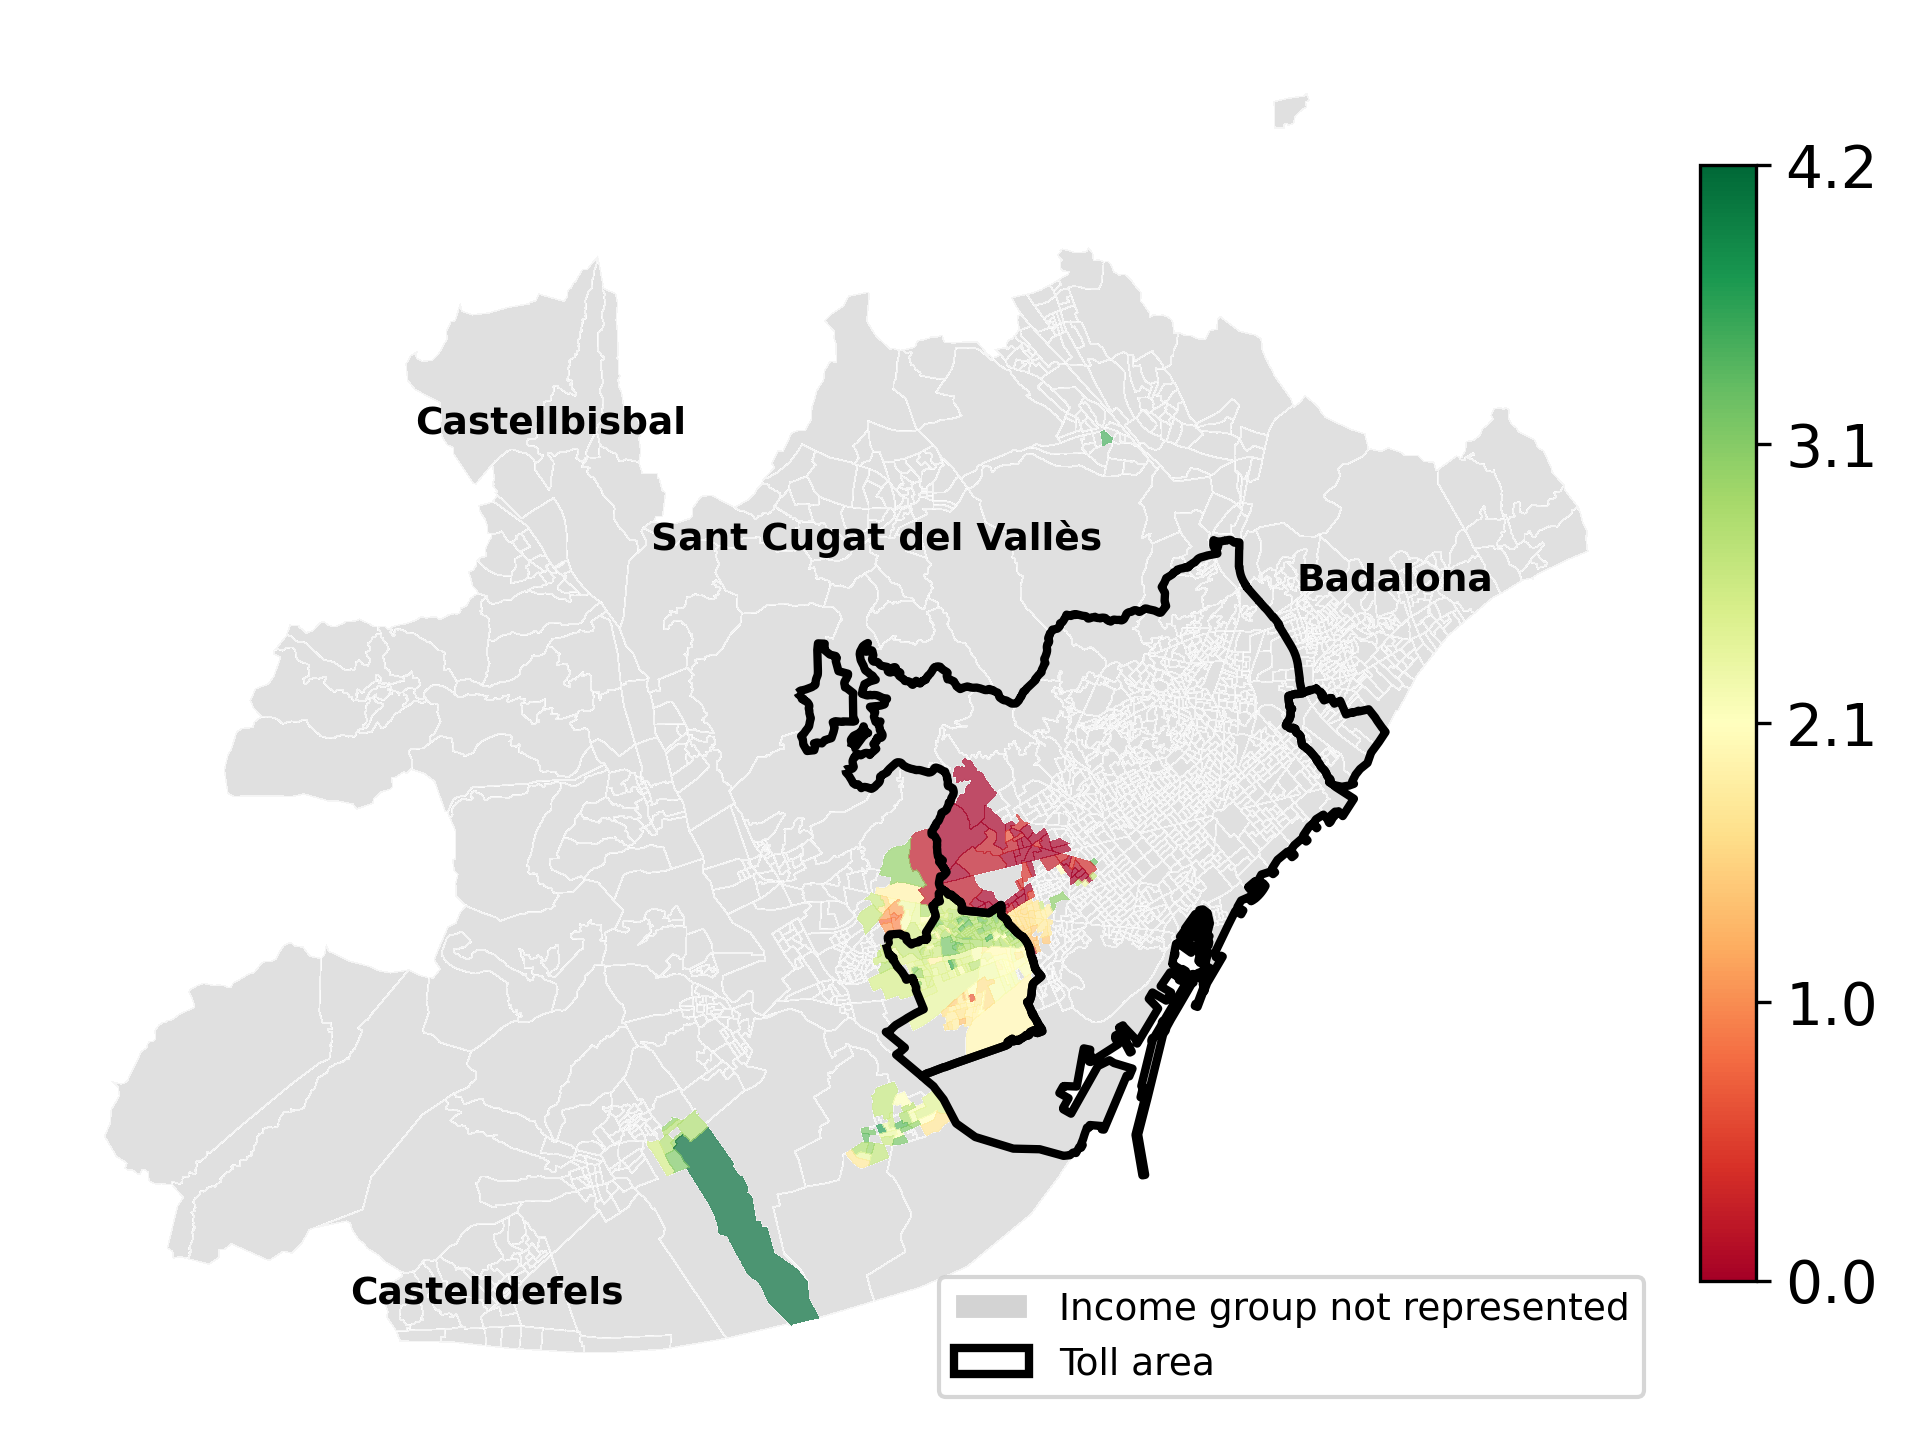

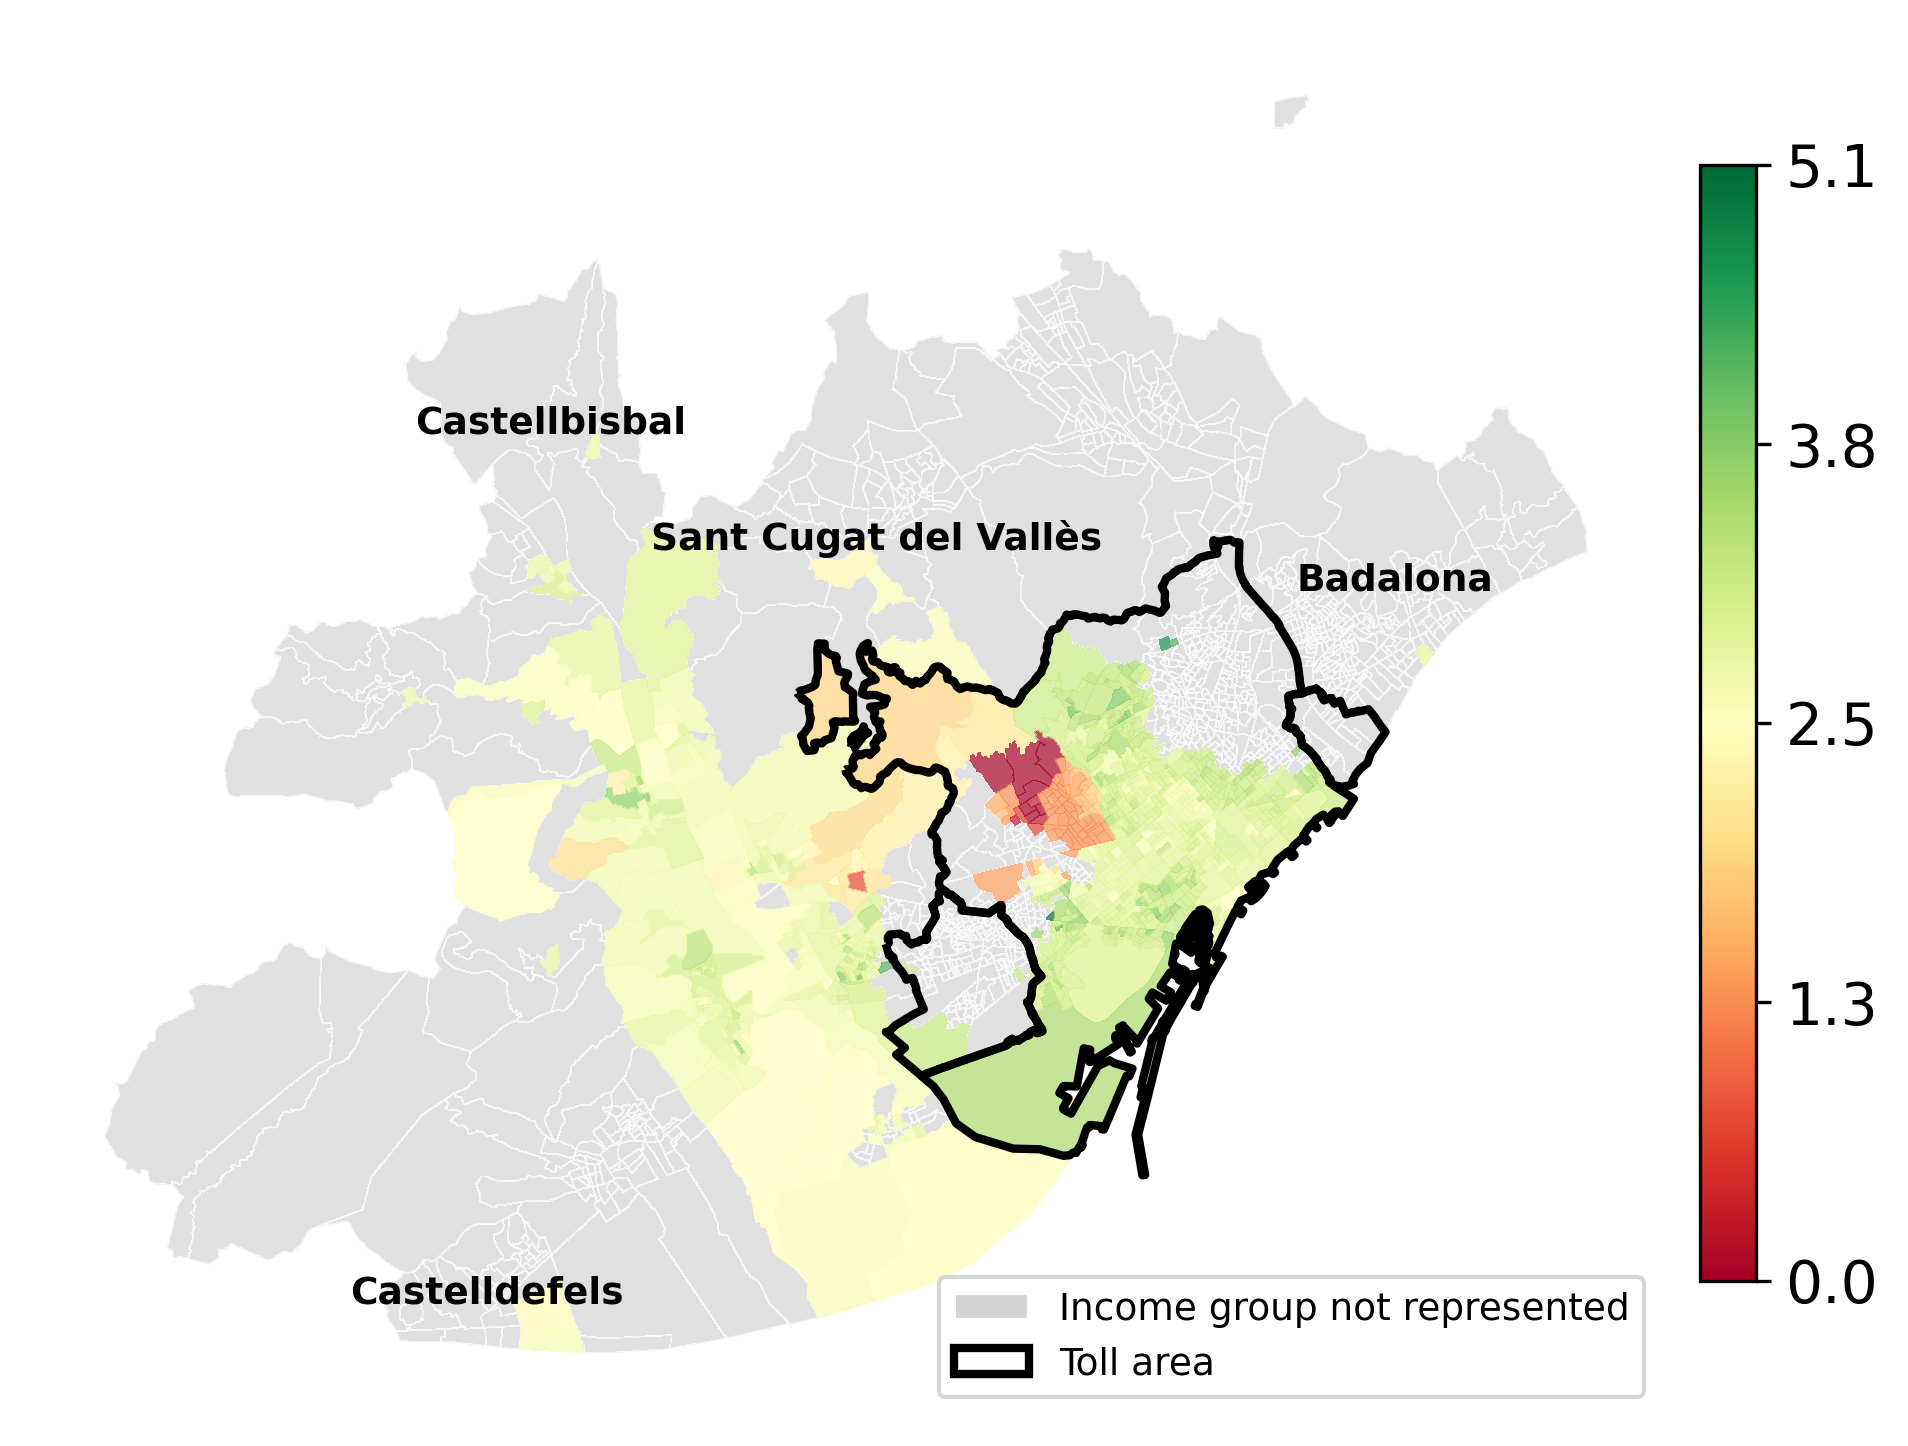

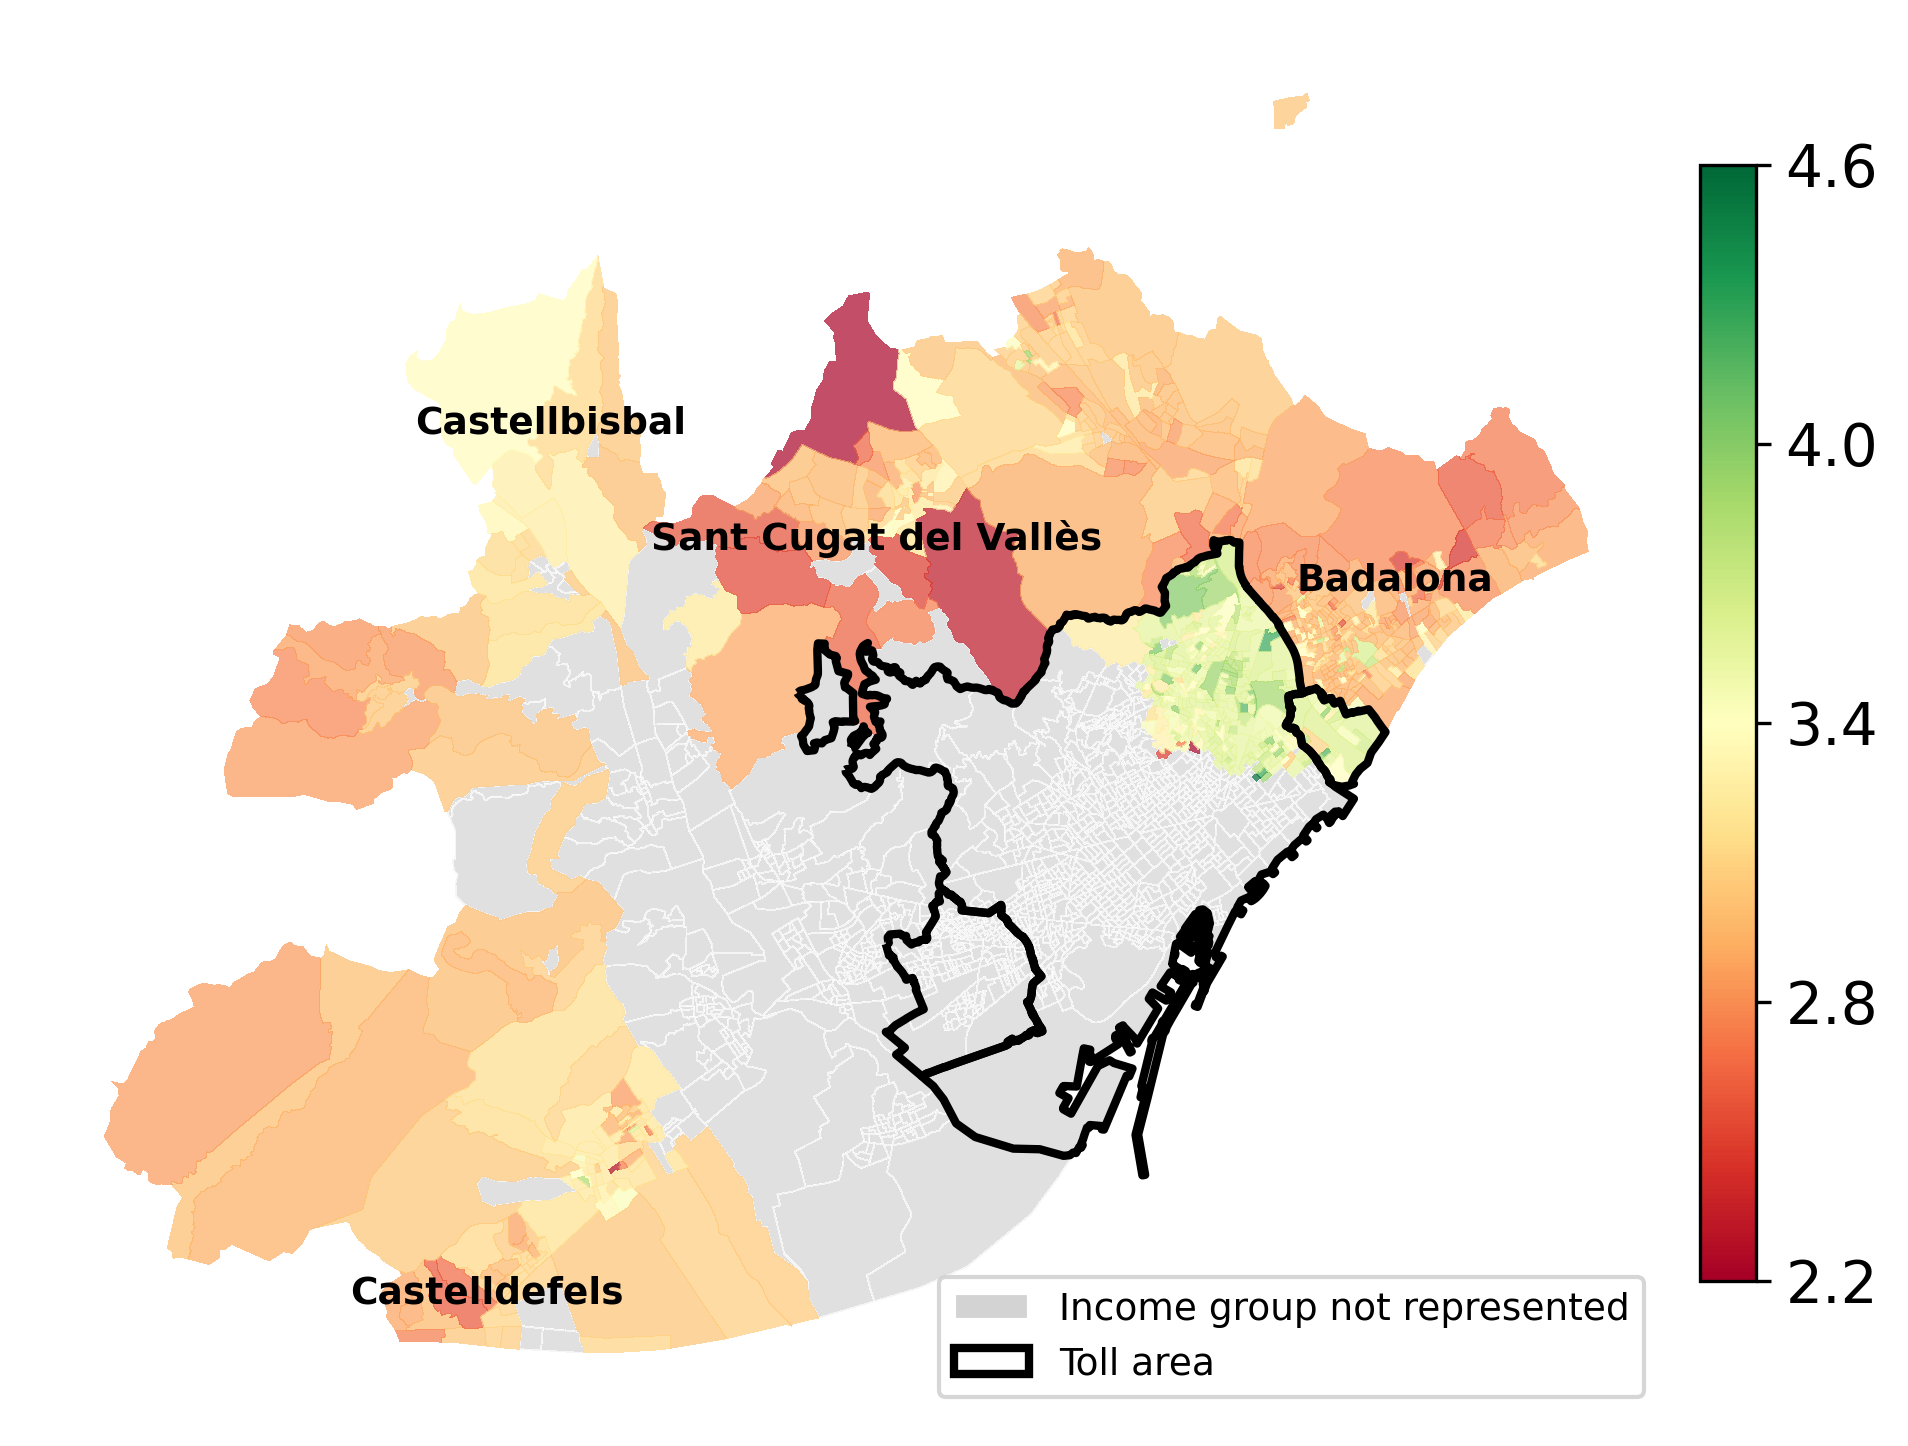

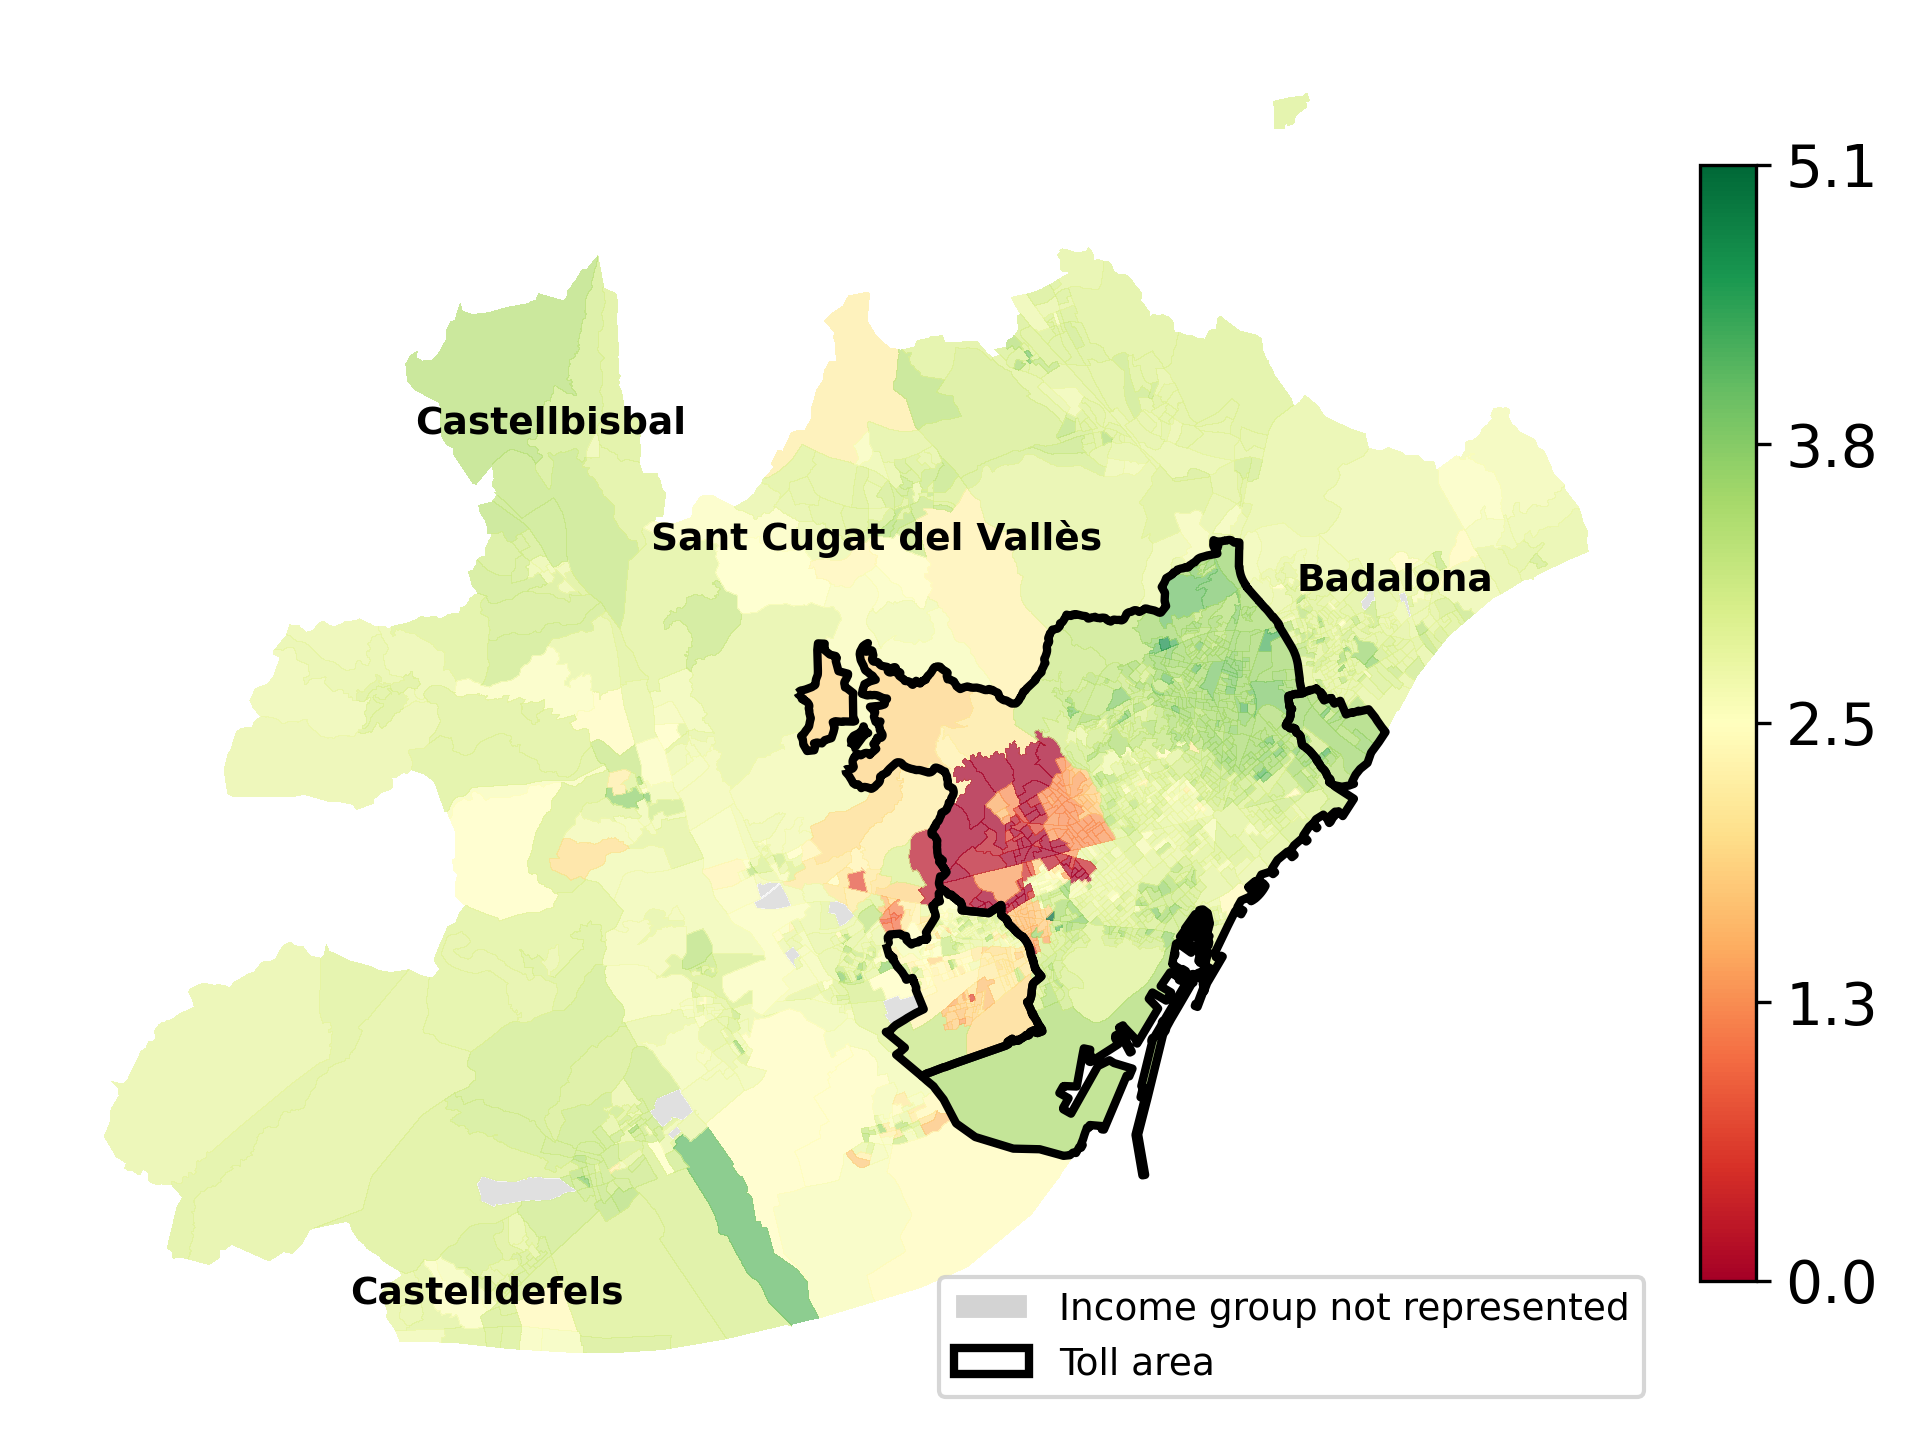

In [ ]:
#Spatial analysis plot: price
weighted_values = {
    lvl: compute_weighted_mean_opinions(acceptable_price[lvl], indiv_loc_matrix[lvl], N[lvl]) * 2
    for lvl in income_levels}

for lvl in income_levels:
    plot_spatial_price(gdf, weighted_values[lvl])

weighted_values_nonan = weighted_values.copy()
for lvl in income_levels:
    weighted_values_nonan[lvl][np.isnan(weighted_values_nonan[lvl])] = 0

weighted_values_all = ((weighted_values_nonan["LOW"] * np.nansum(indiv_loc_matrix["LOW"], 0)) + (weighted_values_nonan["MED"] * np.nansum(indiv_loc_matrix["MED"], 0)) + (weighted_values_nonan["HIGH"] * np.nansum(indiv_loc_matrix["HIGH"], 0))) / (np.nansum(indiv_loc_matrix["LOW"], 0) + np.nansum(indiv_loc_matrix["MED"], 0) + np.nansum(indiv_loc_matrix["HIGH"], 0))
plot_spatial_price(gdf, weighted_values_all)

In [ ]:
def plot_spatial_price(gdf, values, include_missing = True):
    # --- prepare values ---
    gdf_proj = gdf.to_crs(epsg=32632).copy()   # keep projection if needed
    gdf_proj["value"] = values

    # Dissolve by municipality to get one polygon per municipality
    muni_gdf = gdf_proj.dissolve(by='NMUN', as_index=False)
    muni_gdf['centroid'] = muni_gdf.geometry.centroid
    muni_gdf['x'] = muni_gdf.centroid.x
    muni_gdf['y'] = muni_gdf.centroid.y

    # plotting
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    cmap_name = "RdYlGn"
    vmin, vmax = gdf_proj["value"].min(), gdf_proj["value"].max()

    missing = gdf_proj[gdf_proj["value"].isna()]
    present = gdf_proj[gdf_proj["value"].notna()]

    # First: plot missing polygons in grey
    missing.plot(color="lightgrey", edgecolor="white",
             linewidth=0.2, ax=ax, label="Missing data")
    present.plot(column="value",
                  cmap=cmap_name,
                  vmin=vmin, vmax=vmax,
                  linewidth=0, edgecolor="grey",
                  ax=ax)

    ax.set_axis_off()

    # improve rendering
    for coll in ax.collections:
        coll.set_antialiased(False)
        coll.set_alpha(0.7)

    for _, row in muni_gdf.loc[muni_gdf["NMUN"].isin(["Badalona", "Castelldefels", "Castellbisbal", "Sant Cugat del Vallès"]),:].iterrows():
        ax.text(row.x, row.y, row['NMUN'], fontsize=9, fontweight='bold', ha='center', va='center', color='black')
    
    
    city_border = muni_gdf[muni_gdf.ID.str[:5].isin(["08019", "08101", "08194"])]
    city_border.boundary.plot(ax=ax, color='black', linewidth=2, label = "Toll area")
    
    # continuous colorbar (no title)
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    ticks = np.linspace(vmin, vmax, 5)
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f"{t:.1f}" for t in ticks], fontsize=14)  # show 1 decimal + %

    if include_missing == True:
        missing_patch = mpatches.Patch(facecolor="lightgrey", edgecolor="white", label="Population = 0")
    
    toll_patch = mpatches.Patch(facecolor="none", edgecolor="black", linewidth=2, label="Toll area")

    if include_missing == True:
        ax.legend(handles=[missing_patch, toll_patch], loc="lower right")
    else:
        ax.legend(handles=[toll_patch], loc="lower right")

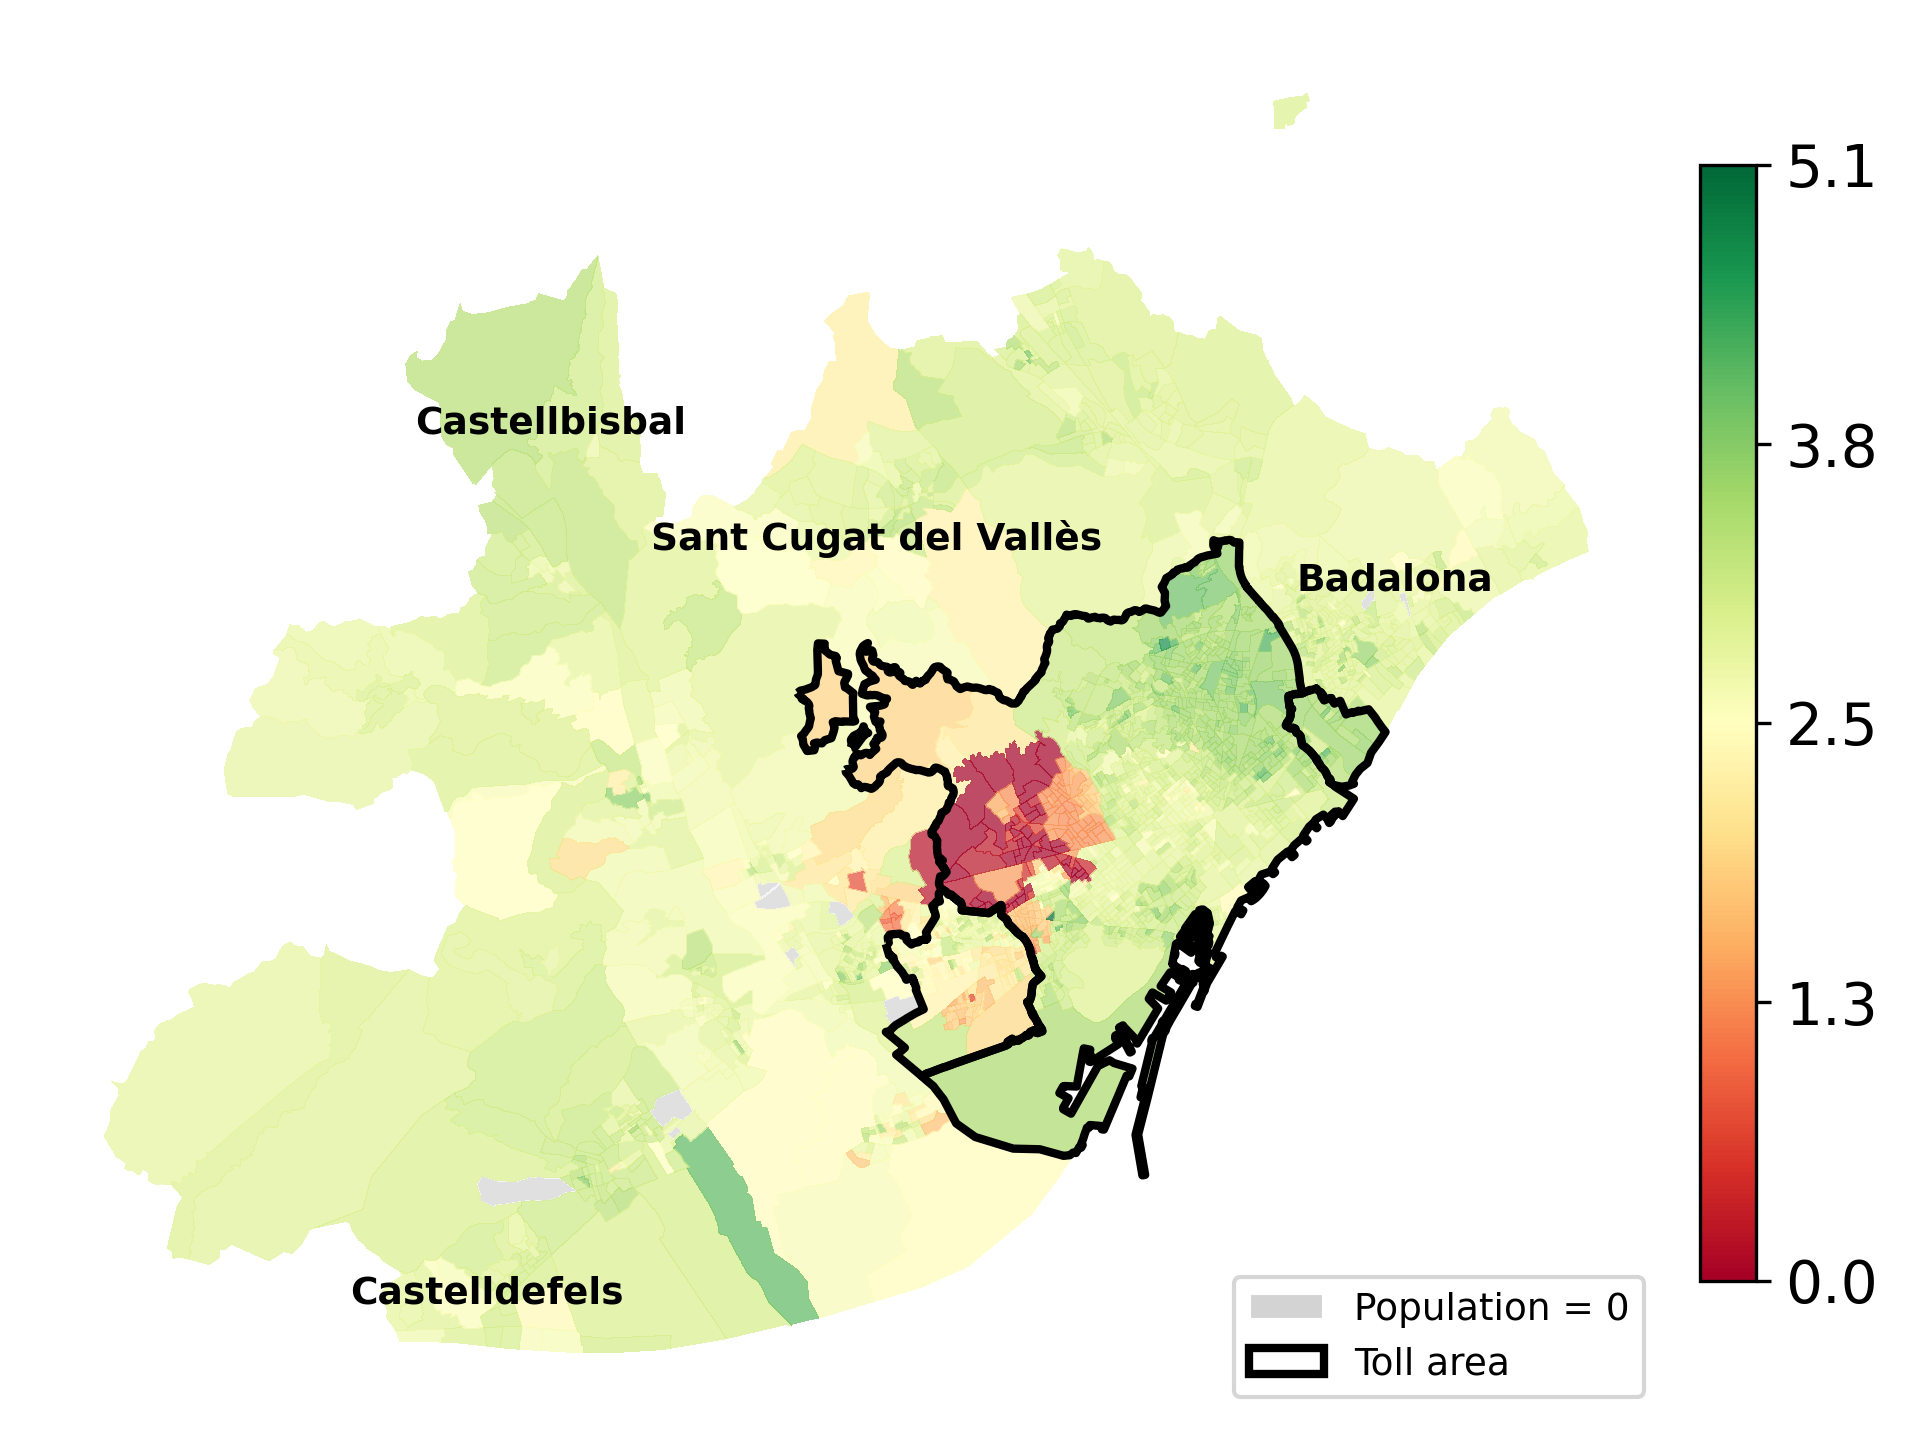

In [ ]:
plot_spatial_price(gdf, weighted_values_all)

In [ ]:
def plot_spatial_price(gdf, values, include_missing = True):
    # --- prepare values ---
    gdf_proj = gdf.to_crs(epsg=32632).copy()   # keep projection if needed
    gdf_proj["value"] = values

    # Dissolve by municipality to get one polygon per municipality
    muni_gdf = gdf_proj.dissolve(by='NMUN', as_index=False)
    muni_gdf['centroid'] = muni_gdf.geometry.centroid
    muni_gdf['x'] = muni_gdf.centroid.x
    muni_gdf['y'] = muni_gdf.centroid.y

    # plotting
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    cmap_name = "RdYlGn"
    vmin, vmax = gdf_proj["value"].min(), gdf_proj["value"].max()

    missing = gdf_proj[gdf_proj["value"].isna()]
    present = gdf_proj[gdf_proj["value"].notna()]

    # First: plot missing polygons in grey
    missing.plot(color="lightgrey", edgecolor="white",
             linewidth=0.2, ax=ax, label="Missing data")
    present.plot(column="value",
                  cmap=cmap_name,
                  vmin=vmin, vmax=vmax,
                  linewidth=0, edgecolor="grey",
                  ax=ax)

    ax.set_axis_off()

    # improve rendering
    for coll in ax.collections:
        coll.set_antialiased(False)
        coll.set_alpha(0.7)

    for _, row in muni_gdf.loc[muni_gdf["NMUN"].isin(["Badalona", "Castelldefels", "Castellbisbal", "Sant Cugat del Vallès"]),:].iterrows():
        ax.text(row.x, row.y, row['NMUN'], fontsize=9, fontweight='bold', ha='center', va='center', color='black')
    
    
    city_border = muni_gdf[muni_gdf.ID.str[:5].isin(["08019", "08101", "08194"])]
    city_border.boundary.plot(ax=ax, color='black', linewidth=2, label = "Toll area")
    
    # continuous colorbar (no title)
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    ticks = np.linspace(vmin, vmax, 5)
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f"{t:.1f}" for t in ticks], fontsize=14)  # show 1 decimal + %

    if include_missing == True:
        missing_patch = mpatches.Patch(facecolor="lightgrey", edgecolor="white", label="Simulated population = 0")
    
    toll_patch = mpatches.Patch(facecolor="none", edgecolor="black", linewidth=2, label="Toll area")

    if include_missing == True:
        ax.legend(handles=[missing_patch, toll_patch], loc="lower right")
    else:
        ax.legend(handles=[toll_patch], loc="lower right")

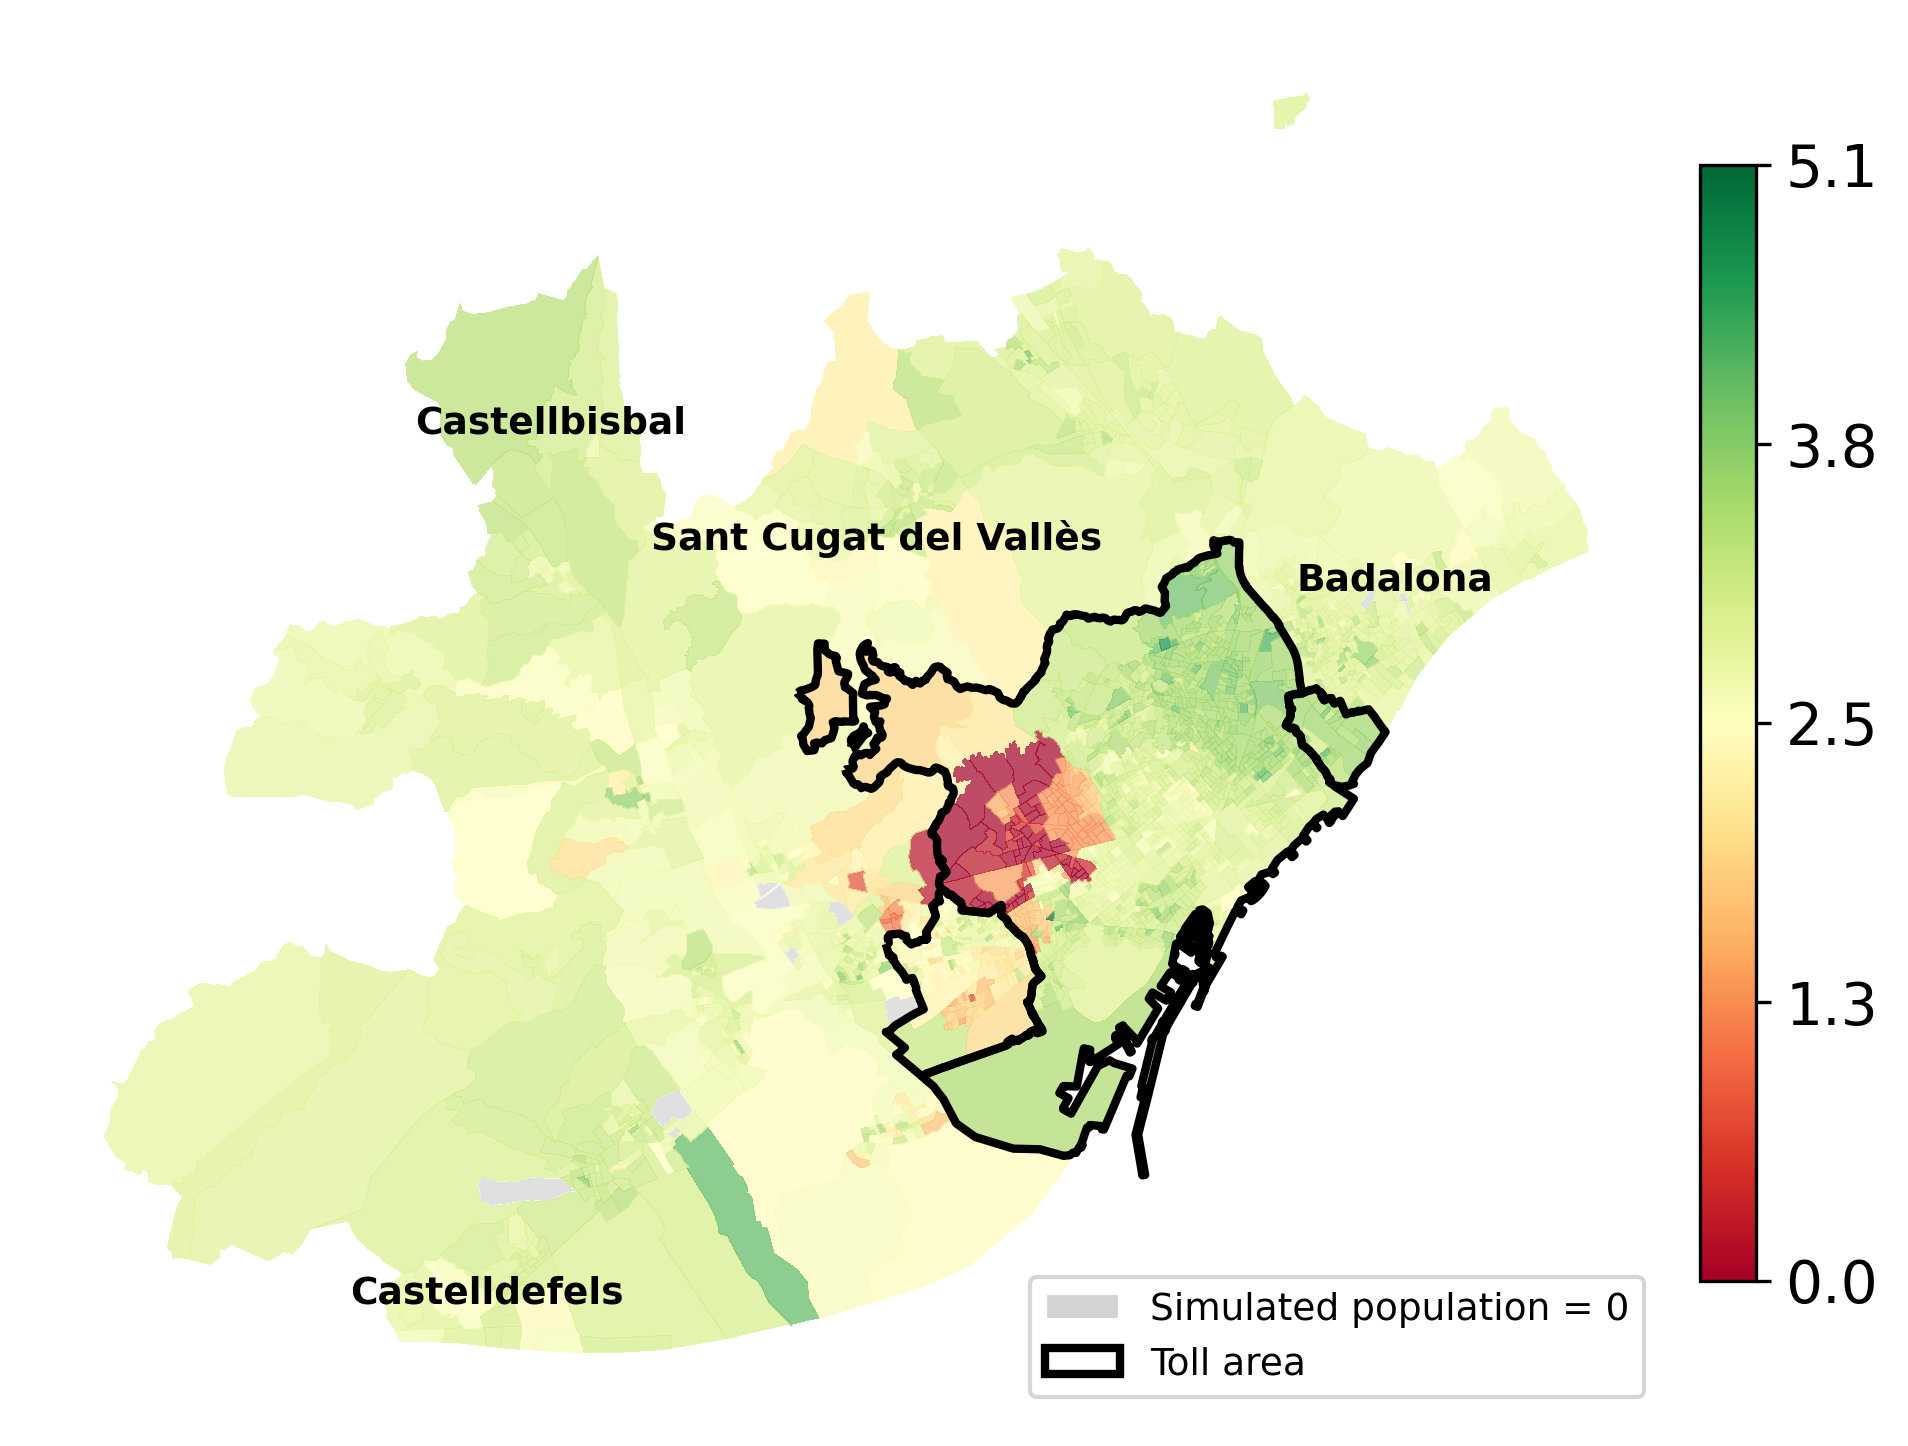

In [ ]:
plot_spatial_price(gdf, weighted_values_all)

min -62.5
max 166.66666666666666


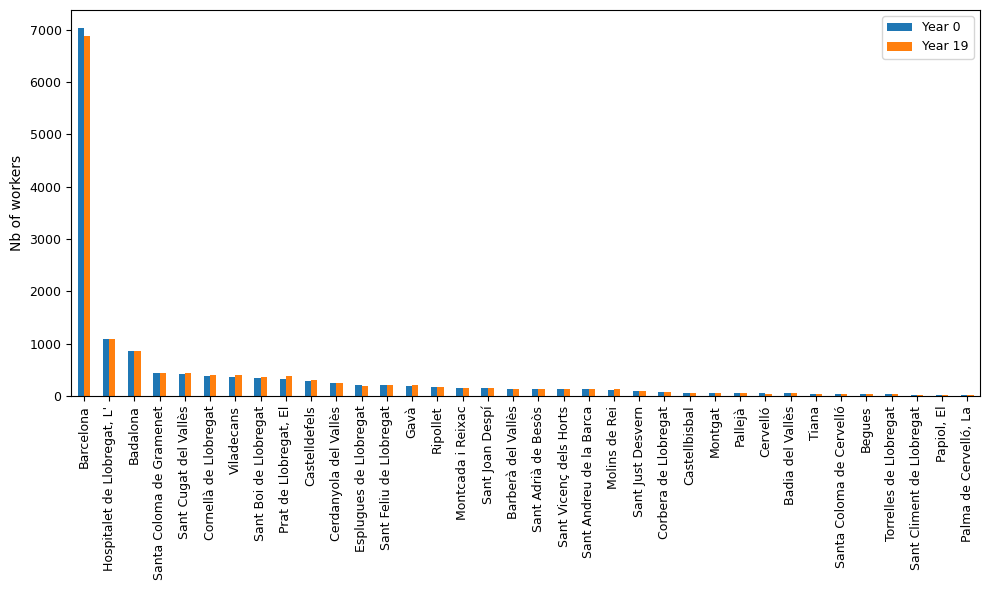

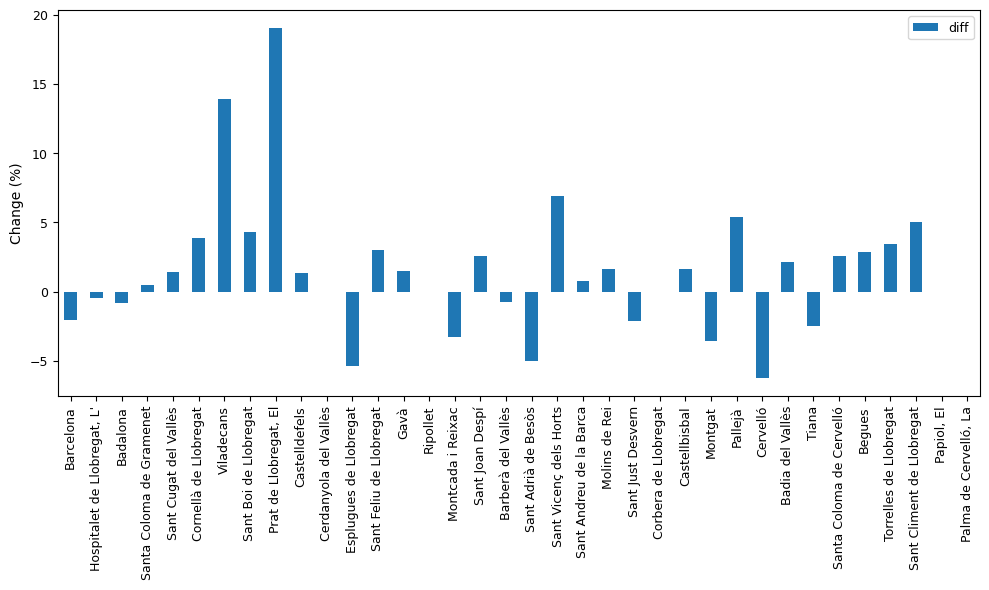

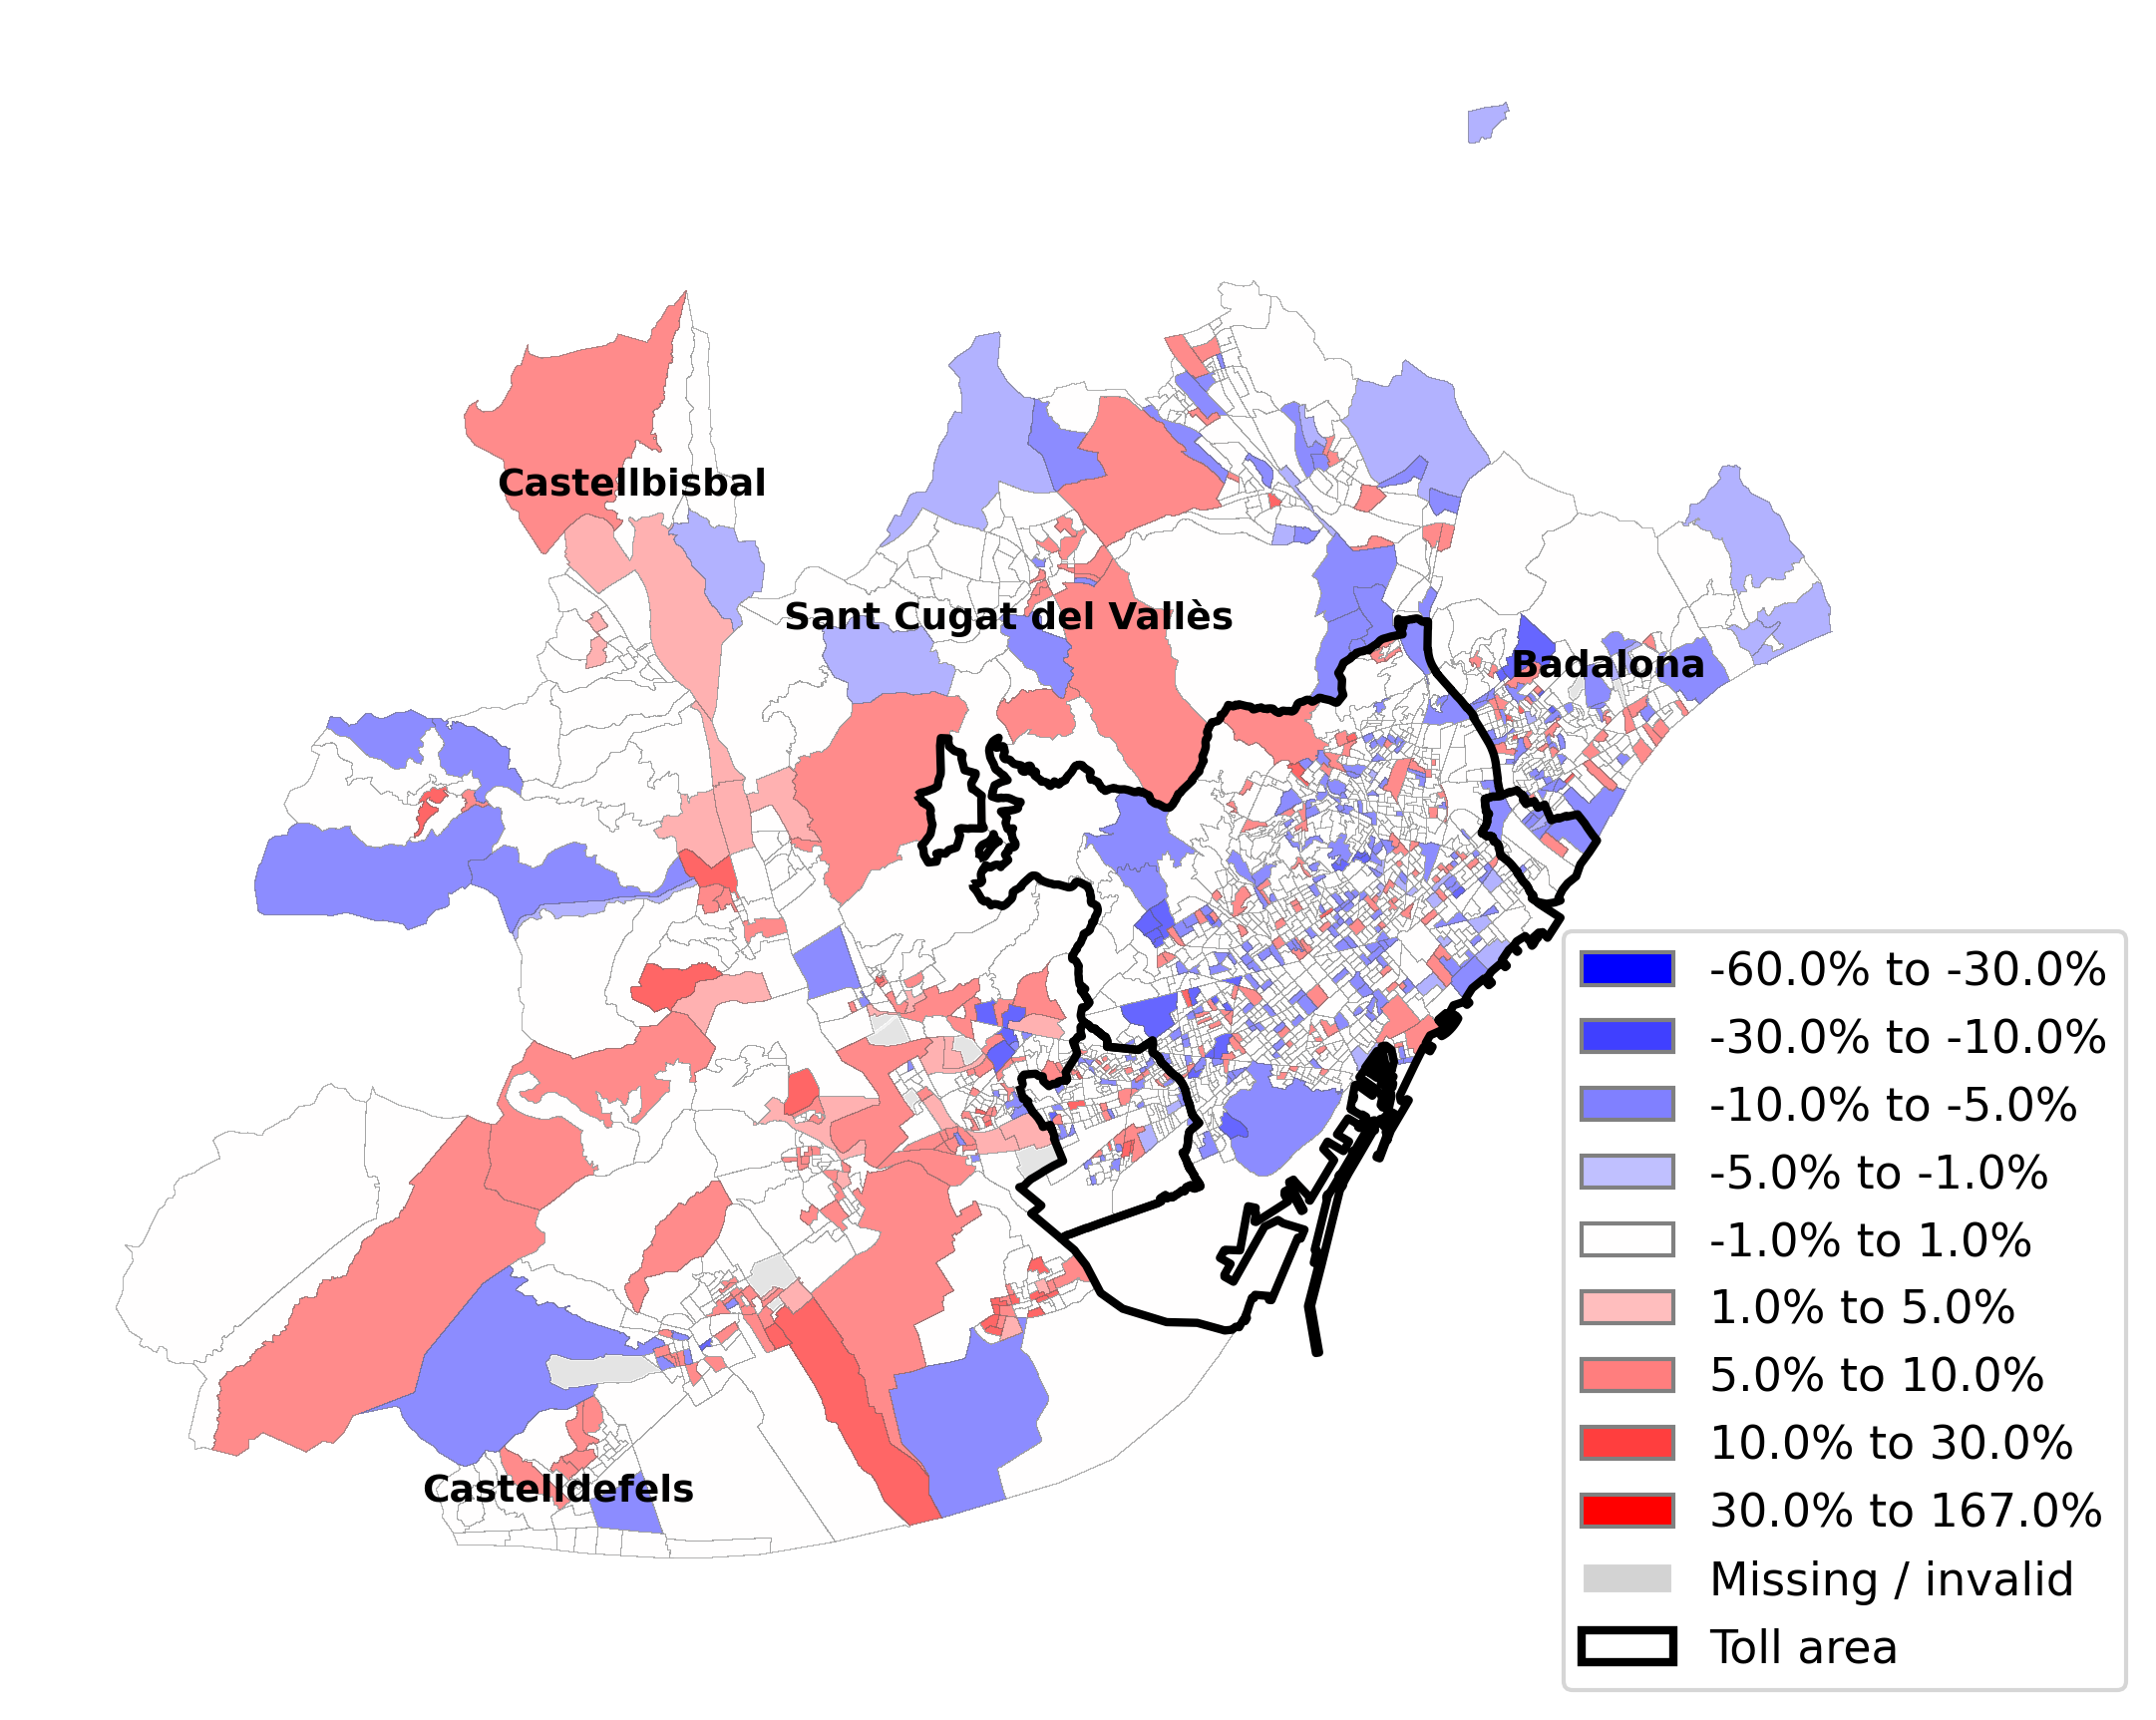

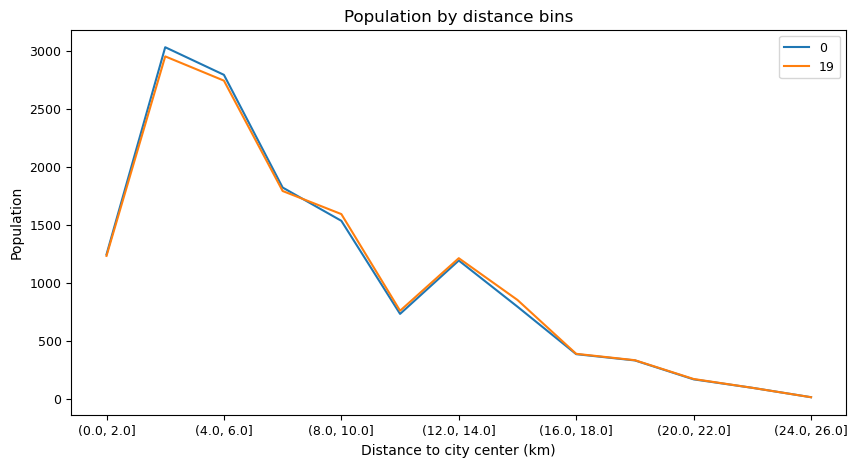

LOW 17.490161783996502 % moving relative to the population
MED 11.22667482410523 % moving relative to the population
HIGH 11.067193675889328 % moving relative to the population


In [ ]:
#Spatial analysis plot: population
plot_change_population_custom(gdf, save_population, bins=[-60, -30, -10, -5, -1, 1, 5, 10, 30, 167],cmap_name="bwr",)
plot_change_pop_line(gdf, save_population)
print_moving(save_population_lvl, income_levels, N)

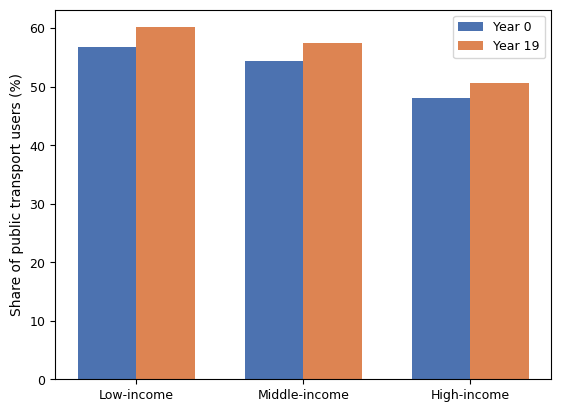

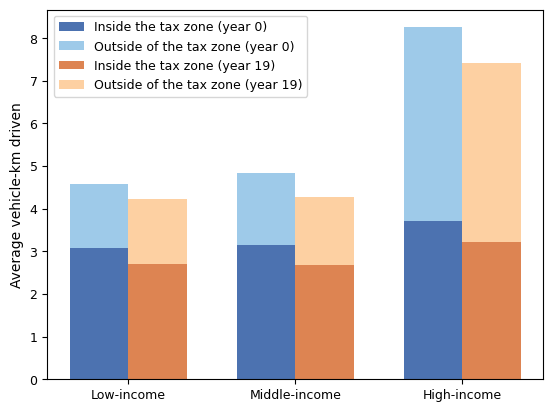

<Figure size 640x480 with 0 Axes>

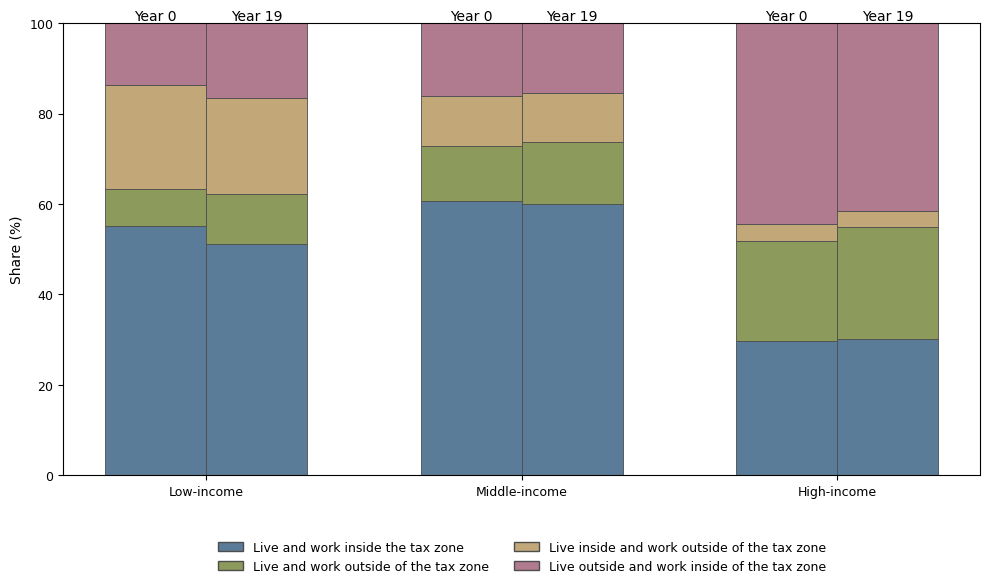

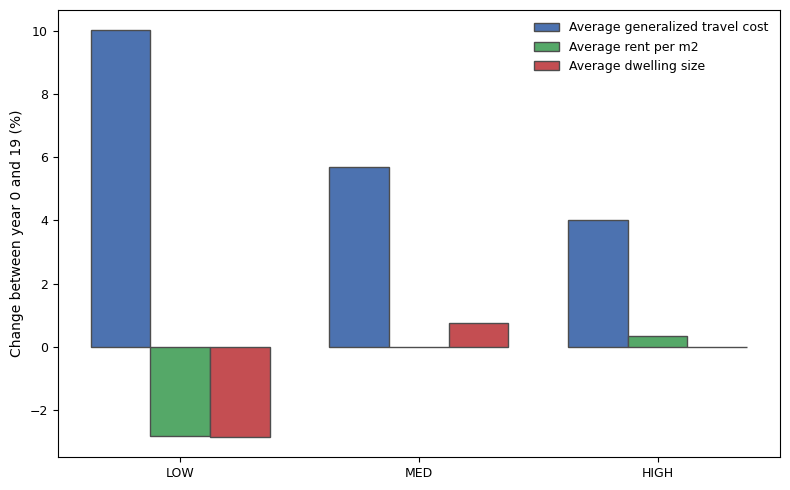

In [ ]:
plot_mode_shares(mode_shares_lvl, income_levels, MAX_YEAR)
plot_vkm(avg_vkm_in_zone_lvl, avg_vkm_out_zone_lvl, MAX_YEAR, income_levels)
plot_living_commuting_pattern(live_and_work_in_toll_lvl, live_out_and_work_out_lvl, live_in_toll_and_work_out_lvl, live_out_and_work_in_toll_lvl, MAX_YEAR, income_levels)
compute_change_costs(avg_tcost_lvl, avg_rent_lvl, avg_dsize_lvl, MAX_YEAR, income_levels)